In [25]:
%reload_ext autoreload
%autoreload 2
from analysis_stm import MotionAnalyzer,ExpMetaData, DiffusionPlotter
import numpy as np
from scipy.optimize import curve_fit
import trackpy as tp
from PIL import Image
import matplotlib.pyplot as plt
from sxmreader import SXMReader

In [9]:
#-60Vg
emds=[]
Vg = 60
voltages_temperatures = np.linspace(1.4, 2.0, 1, np.float32)
START = 616
SIZE = 1
FOLDER = "electromigration_13"
sets = [range(616,640)]
emd = ExpMetaData(sets, Vg, voltages_temperatures, FOLDER)
emds.append(emd)

#-50Vg

In [34]:
import inspect


In [35]:
inspect.getsourcefile(tp.locate)

'/Users/lucnguyen/opt/anaconda3/envs/elmloc/lib/python3.7/site-packages/trackpy/feature.py'

In [33]:
path=f'/Users/lucnguyen/Desktop/URAP CROMMIE STUFF/molecule_tracking-master/phase_test/Image_924 Image Z (m).jpg'
img = Image.open(path)
img = img.resize((200,200),)

img=img.convert('L')

img.shape=img.size

img.ndim=2

_kwargs={
    'diameter':5,
    'maxsize':300,
    'minmass':100,
    'separation':5,}

f=tp.locate(img,**_kwargs).reset_index()
f

,index,y,x,mass,size,ecc,orientation,angle,signal,raw_mass,ep
0,0,2.404274,127.154052,209.475922,1.180504,0.263691,-2.388783,-2.388783,37.306487,1079.0,0.041647
1,1,2.436394,166.085931,221.413998,1.193213,0.300274,3.006533,3.006533,38.052616,1336.0,0.032077
2,2,2.701981,50.055125,216.564155,1.137415,0.083238,0.275377,0.275377,39.358343,1336.0,0.032077
3,3,2.637160,73.929886,212.833506,1.140444,0.099468,-0.010733,-0.010733,37.866084,1341.0,0.031935
4,4,2.760870,104.881739,214.512298,1.137121,0.125820,0.048588,0.048588,39.171811,1168.0,0.037747
...,...,...,...,...,...,...,...,...,...,...,...
381,381,195.676923,123.954701,218.242946,1.164650,0.321831,2.719883,2.719883,38.239149,1274.0,0.033960
382,382,196.015293,184.281223,219.548673,1.134535,0.351176,-2.967456,-2.967456,40.291005,1162.0,0.037987
383,383,197.020472,14.956693,236.896190,1.133248,0.399026,3.141037,3.141037,45.700446,1323.0,0.032455
384,384,196.589271,26.954736,222.533192,1.157359,0.143138,0.849236,0.849236,39.917941,1199.0,0.036555


In [10]:

m = MotionAnalyzer(emd.sets, emd.voltages_temperatures,
                   emd.folder, heater=False, drift_correction = False,)
m.analyze(plot_gif = False)


Frame 23: 16 trajectories present.
Before: 190
After: 185


/Users/lucnguyen/opt/anaconda3/envs/elmloc/lib/python3.7/site-packages/trackpy/motion.py:238: FutureWarning: Using the level keyword in DataFrame and Series aggregations is deprecated and will be removed in a future version. Use groupby instead. df.median(level=1) should use df.groupby(level=1).median().
  results = msds.mul(msds['N'], axis=0).mean(level=1)  # weighted average
/Users/lucnguyen/opt/anaconda3/envs/elmloc/lib/python3.7/site-packages/trackpy/motion.py:239: FutureWarning: Using the level keyword in DataFrame and Series aggregations is deprecated and will be removed in a future version. Use groupby instead. df.median(level=1) should use df.groupby(level=1).median().
  results = results.div(msds['N'].mean(level=1), axis=0)  # weights normalized
/Users/lucnguyen/opt/anaconda3/envs/elmloc/lib/python3.7/site-packages/trackpy/motion.py:245: FutureWarning: Using the level keyword in DataFrame and Series aggregations is deprecated and will be removed in a future version. Use groupb

In [26]:
dp=DiffusionPlotter(m)
dp.rots[0]

/Users/lucnguyen/Desktop/URAP CROMMIE STUFF/molecule_tracking-master/analysis_stm.py:423: RuntimeWarning: invalid value encountered in reciprocal
  result = linregress(np.reciprocal(tmpv), np.log(_sorted_D_constants))
/Users/lucnguyen/opt/anaconda3/envs/elmloc/lib/python3.7/site-packages/scipy/stats/_stats_mstats_common.py:170: RuntimeWarning: invalid value encountered in double_scalars
  slope = ssxym / ssxm
/Users/lucnguyen/opt/anaconda3/envs/elmloc/lib/python3.7/site-packages/scipy/stats/_stats_mstats_common.py:184: RuntimeWarning: invalid value encountered in sqrt
  t = r * np.sqrt(df / ((1.0 - r + TINY)*(1.0 + r + TINY)))
/Users/lucnguyen/opt/anaconda3/envs/elmloc/lib/python3.7/site-packages/scipy/stats/_stats_mstats_common.py:187: RuntimeWarning: invalid value encountered in double_scalars
  slope_stderr = np.sqrt((1 - r**2) * ssym / ssxm / df)
/Users/lucnguyen/Desktop/URAP CROMMIE STUFF/molecule_tracking-master/analysis_stm.py:424: RuntimeWarning: invalid value encountered in re

,index,x,y,angle,x_b,y_b,angle_b,dx,dy,dr,direction,orientation,orientation_b,rotated,VSD
0,1,40.392084,31.885111,-1.137753,40.323600,32.010611,1.123058,-0.122059,0.074444,0.142970,0.808721,0,2,1,1.40
1,7,3.610143,33.968750,-1.055959,3.540659,34.051851,-0.779051,-0.101726,0.037225,0.108323,0.885622,0,0,0,1.40
2,10,42.955430,34.111593,-0.724214,43.476390,34.431418,-0.218556,0.291252,0.537457,0.611300,0.215073,0,1,1,1.40
3,12,10.087459,34.955468,-0.731761,9.725376,35.491701,-0.885385,-0.581690,0.283349,0.647031,0.845589,0,0,0,1.40
4,13,19.635433,35.139006,-0.845160,19.995180,35.484566,-0.323026,0.138770,0.479137,0.498828,0.298940,0,1,1,1.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
282,1724,30.976986,7.154372,0.706938,31.027136,7.178570,0.380122,-0.055530,0.004119,0.055683,0.175611,2,1,1,1.40
283,1726,33.406514,8.234544,0.862941,33.017151,8.005565,0.996705,0.451688,0.003620,0.451702,-1.019523,2,2,0,1.40
284,1727,30.990718,7.580185,1.190704,31.419439,7.442822,0.828057,-0.302602,0.333320,0.450189,-0.121120,2,2,0,1.40
285,1729,31.419439,7.442822,0.828057,32.249535,7.474545,0.993294,-0.734746,0.387576,0.830702,0.014921,2,2,0,1.40


/Users/lucnguyen/Desktop/URAP CROMMIE STUFF/molecule_tracking-master/analysis_stm.py:806: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  palette=palette,
/Users/lucnguyen/Desktop/URAP CROMMIE STUFF/molecule_tracking-master/analysis_stm.py:862: UserWarning: 'set_params()' not defined for locator of type <class 'matplotlib.category.StrCategoryLocator'>
  def _overlay_diffusion_grid(self, ax, plotrange = 6, theta = 0, **kwargs):


(<seaborn.axisgrid.FacetGrid at 0x7fde600986d0>,
 <Figure size 900x600 with 1 Axes>,
      index          x          y     angle        x_b        y_b   angle_b  \
 0        1  40.392084  31.885111 -1.137753  40.323600  32.010611  1.123058   
 1        7   3.610143  33.968750 -1.055959   3.540659  34.051851 -0.779051   
 2       10  42.955430  34.111593 -0.724214  43.476390  34.431418 -0.218556   
 3       12  10.087459  34.955468 -0.731761   9.725376  35.491701 -0.885385   
 4       13  19.635433  35.139006 -0.845160  19.995180  35.484566 -0.323026   
 ..     ...        ...        ...       ...        ...        ...       ...   
 282   1724  30.976986   7.154372  0.706938  31.027136   7.178570  0.380122   
 283   1726  33.406514   8.234544  0.862941  33.017151   8.005565  0.996705   
 284   1727  30.990718   7.580185  1.190704  31.419439   7.442822  0.828057   
 285   1729  31.419439   7.442822  0.828057  32.249535   7.474545  0.993294   
 286   1740  32.249535   7.474545  0.993294  3

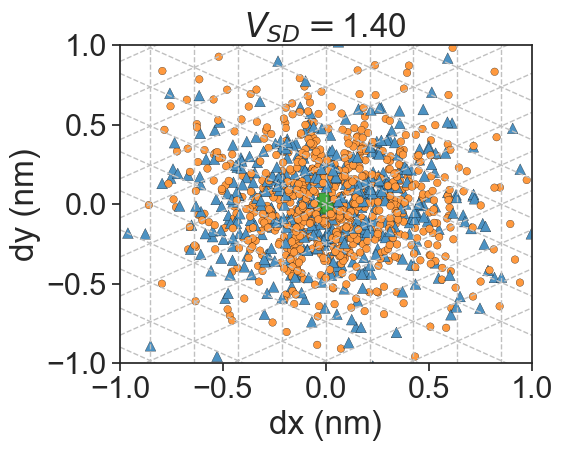

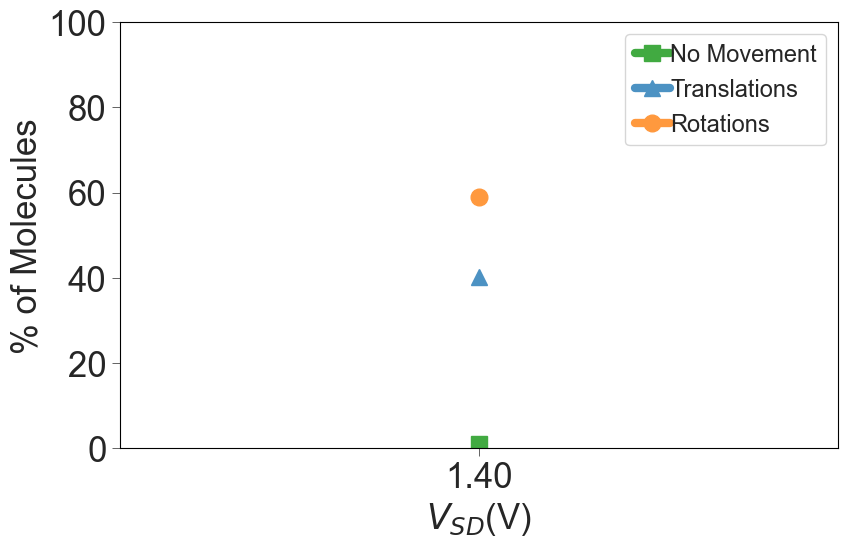

In [27]:
dp.plot_scatter_rot()

In [32]:
m.t3s[0]

,y,x,mass,size,ecc,orientation,angle,signal,raw_mass,ep,frame,particle
frame_index,,,,,,,,,,,,
0,5.118597,56.086860,3.056832,2.234449,0.004844,-0.005663,-0.005663,0.222965,-61.852017,-0.123051,0,0
0,81.625885,103.403735,2.643240,1.796469,0.159683,-2.912648,-2.912648,0.195733,37.459077,0.650905,0,1
0,82.669069,18.124925,2.833867,1.820636,0.048821,-0.243766,-0.243766,0.200839,32.227291,0.973458,0,2
0,83.975452,42.941860,2.634730,1.704607,0.121430,2.419426,2.419426,0.202541,30.968201,1.105272,0,3
0,84.099727,69.120902,2.491760,1.675727,0.119102,3.122359,3.122359,0.199137,31.801407,1.014377,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...
23,22.764468,120.045087,3.500904,2.755027,0.601473,-3.101308,-3.101308,0.176694,1.977345,-0.118590,23,120
23,24.958730,91.331746,2.968465,3.674235,0.254303,-2.460326,-2.460326,0.103661,-16.089934,-0.065137,23,117
23,18.549104,80.389431,10.387273,2.100233,0.078969,0.475663,0.475663,0.600761,-22.184994,-0.056540,23,103


In [24]:
emds=[] 

#-60Vg
Vg = -60
voltages_temperatures = np.linspace(1.4, 2.0, 7, np.float32)
START = 636
SIZE = 8
FOLDER = "electromigration_33"
sets = [range(START + SIZE * i, START + SIZE * (i + 1) + 1) for i in range(len(voltages_temperatures))]
emd = ExpMetaData(sets, Vg, voltages_temperatures, FOLDER)
emds.append(emd)

#-50Vg
Vg = -50
voltages_temperatures = np.linspace(0.95, 1.37, 8, np.float32)
START = 357
SIZE = 8
FOLDER = "electromigration_34"
sets = [range(START + SIZE * i, START + SIZE * (i + 1) + 1) for i in range(len(voltages_temperatures))]
emd = ExpMetaData(sets, Vg, voltages_temperatures, FOLDER)
emds.append(emd)



#-40Vg
Vg = -40
voltages_temperatures = np.linspace(0.64, 0.92, 8, np.float32)
START = 463
SIZE = 8
FOLDER = "electromigration_33"
sets = [range(START + SIZE * i, START + SIZE * (i + 1) + 1) for i in range(len(voltages_temperatures))]
emd = ExpMetaData(sets, Vg, voltages_temperatures, FOLDER)
emds.append(emd)

#-30Vg
Vg = -30
voltages_temperatures = np.linspace(0.34, 0.55, 8, np.float32)
START = 371
SIZE = 8
FOLDER = "electromigration_33"
sets = [range(START + SIZE * i, START + SIZE * (i + 1) + 1) for i in range(len(voltages_temperatures))]
emd = ExpMetaData(sets, Vg, voltages_temperatures, FOLDER)
emds.append(emd)

#-20Vg
Vg = -20
voltages_temperatures = np.linspace(0.44, 0.72, 8, np.float32)
START = 268
SIZE = 8
FOLDER = "electromigration_34"
sets = [range(START + SIZE * i, START + SIZE * (i + 1) + 1) for i in range(len(voltages_temperatures))]
emd = ExpMetaData(sets, Vg, voltages_temperatures, FOLDER)
emds.append(emd)



#-10Vg
Vg = -10
voltages_temperatures = np.linspace(0.7, 1.05, 8, np.float32)
START = 731
SIZE = 8
FOLDER = "electromigration_33"
sets = [range(START + SIZE * i, START + SIZE * (i + 1) + 1) for i in range(len(voltages_temperatures))]
emd = ExpMetaData(sets, Vg, voltages_temperatures, FOLDER)
emds.append(emd)

#0Vg
Vg = 0
voltages_temperatures = np.linspace(0.75, 1.05, 7, np.float32)
START = 825
SIZE = 8
FOLDER = "electromigration_33"
sets = [range(START + SIZE * i, START + SIZE * (i + 1) + 1) for i in range(len(voltages_temperatures))]
emd = ExpMetaData(sets, Vg, voltages_temperatures, FOLDER)
emds.append(emd)

#10Vg
Vg = 10
voltages_temperatures = np.linspace(0.7, 1.05, 8, np.float32)
START = 908
SIZE = 8
FOLDER = "electromigration_33"
sets = [range(START + SIZE * i, START + SIZE * (i + 1) + 1) for i in range(len(voltages_temperatures))]
emd = ExpMetaData(sets, Vg, voltages_temperatures, FOLDER)
emds.append(emd)

#20Vg
Vg = 20
voltages_temperatures = np.linspace(0.7, 1.05, 8, np.float32)
START = 20
SIZE = 8
FOLDER = "electromigration_34"
sets = [range(START + SIZE * i, START + SIZE * (i + 1) + 1) for i in range(len(voltages_temperatures))]
emd = ExpMetaData(sets, Vg, voltages_temperatures, FOLDER)
emds.append(emd)


#30Vg
Vg = 30
voltages_temperatures = np.linspace(0.7, 1.05, 8, np.float32)
START = 103
SIZE = 8
FOLDER = "electromigration_34"
sets = [range(START + SIZE * i, START + SIZE * (i + 1) + 1) for i in range(len(voltages_temperatures))]
emd = ExpMetaData(sets, Vg, voltages_temperatures, FOLDER)
emds.append(emd)

#40Vg
Vg = 40
voltages_temperatures = np.linspace(0.7, 1.05, 8, np.float32)
START = 185
SIZE = 8
FOLDER = "electromigration_34"
sets = [range(START + SIZE * i, START + SIZE * (i + 1) + 1) for i in range(len(voltages_temperatures))]
emd = ExpMetaData(sets, Vg, voltages_temperatures, FOLDER)
emds.append(emd)

#50Vg
Vg = 50
voltages_temperatures = np.linspace(0.7, 1.05, 8, np.float32)
START = 442
SIZE = 8
FOLDER = "electromigration_34"
sets = [range(START + SIZE * i, START + SIZE * (i + 1) + 1) for i in range(len(voltages_temperatures))]
emd = ExpMetaData(sets, Vg, voltages_temperatures, FOLDER)
emds.append(emd)

#60Vg
Vg = 60
voltages_temperatures = np.linspace(0.7, 1.05, 8, np.float32)
START = 524
SIZE = 8
FOLDER = "electromigration_34"
sets = [range(START + SIZE * i, START + SIZE * (i + 1) + 1) for i in range(len(voltages_temperatures))]
emd = ExpMetaData(sets, Vg, voltages_temperatures, FOLDER)
emds.append(emd)
#THIS ONE IS HEATER SERIES


#-60Vg
Vg = -60
voltages_temperatures = np.linspace(28, 34, 7, dtype=np.float32)
START = 188
SIZE = 4
FOLDER = "electromigration_33"
sets = [range(START + SIZE * i, START + SIZE * (i + 1) + 1) for i in range(len(voltages_temperatures))]
emd = ExpMetaData(sets, Vg, voltages_temperatures, FOLDER)
emds.append(emd)

#-50Vg
Vg = -50
voltages_temperatures = np.linspace(25, 30, 6, dtype=np.float32)
START = 153
SIZE = 4
FOLDER = "electromigration_33"
sets = [range(START + SIZE * i, START + SIZE * (i + 1) + 1) for i in range(len(voltages_temperatures))]
emd = ExpMetaData(sets, Vg, voltages_temperatures, FOLDER)
emds.append(emd)

#-40Vg
Vg = -40
voltages_temperatures = np.linspace(20, 26, 7, dtype=np.float32)
START = 814
SIZE = 4
FOLDER = "electromigration_32"
sets = [range(START + SIZE * i, START + SIZE * (i + 1) + 1) for i in range(len(voltages_temperatures))]
emd = ExpMetaData(sets, Vg, voltages_temperatures, FOLDER)
emds.append(emd)

#-30Vg
Vg = -30
voltages_temperatures = np.linspace(16, 21, 6, dtype=np.float32)
START = 104
SIZE = 4
FOLDER = "electromigration_33"
sets = [range(105, 109),
 range(108, 113),
 range(112, 117),
 range(116, 121),
 range(120, 125),
 range(124, 129)]
emd = ExpMetaData(sets, Vg, voltages_temperatures, FOLDER)
emds.append(emd)

#-20Vg
Vg = -20
voltages_temperatures = np.linspace(11, 16, 6, dtype=np.float32)
START = 25
SIZE = 4
FOLDER = "electromigration_33"
sets = [range(START + SIZE * i, START + SIZE * (i + 1) + 1) for i in range(len(voltages_temperatures))]
emd = ExpMetaData(sets, Vg, voltages_temperatures, FOLDER)
emds.append(emd)

#-10Vg
Vg = -10
voltages_temperatures = np.linspace(10, 14, 5, dtype=np.float32)
START = 850
SIZE = 4
FOLDER = "electromigration_32"
sets = [range(START + SIZE * i, START + SIZE * (i + 1) + 1) for i in range(len(voltages_temperatures))]
emd = ExpMetaData(sets, Vg, voltages_temperatures, FOLDER)
emds.append(emd)

#0Vg
Vg = 0
voltages_temperatures = np.linspace(10, 14, 5, dtype=np.float32)
START = 874
SIZE = 4
FOLDER = "electromigration_32"
sets = [range(START + SIZE * i, START + SIZE * (i + 1) + 1) for i in range(len(voltages_temperatures))]
emd = ExpMetaData(sets, Vg, voltages_temperatures, FOLDER)
emds.append(emd)

#10Vg
Vg = 10
voltages_temperatures = np.linspace(10, 14, 5, dtype=np.float32)
START = 902
SIZE = 4
FOLDER = "electromigration_32"
sets = [range(START + SIZE * i, START + SIZE * (i + 1) + 1) for i in range(len(voltages_temperatures))]
emd = ExpMetaData(sets, Vg, voltages_temperatures, FOLDER)
emds.append(emd)

#20Vg
Vg = 20
voltages_temperatures = np.linspace(10, 14, 5, dtype=np.float32)
START = 927
SIZE = 4
FOLDER = "electromigration_32"
sets = [range(START + SIZE * i, START + SIZE * (i + 1) + 1) for i in range(len(voltages_temperatures))]
emd = ExpMetaData(sets, Vg, voltages_temperatures, FOLDER)
emds.append(emd)

#30Vg
Vg = 30
voltages_temperatures = np.linspace(10, 14, 5, dtype=np.float32)
START = 951
SIZE = 4
FOLDER = "electromigration_32"
sets = [range(START + SIZE * i, START + SIZE * (i + 1) + 1) for i in range(len(voltages_temperatures))]
emd = ExpMetaData(sets, Vg, voltages_temperatures, FOLDER)
emds.append(emd)


#40Vg
Vg = 40
voltages_temperatures = np.linspace(11, 14, 4, dtype=np.float32)
START = 218
SIZE = 4
FOLDER = "electromigration_33"
sets = [range(START + SIZE * i, START + SIZE * (i + 1) + 1) for i in range(len(voltages_temperatures))]
emd = ExpMetaData(sets, Vg, voltages_temperatures, FOLDER)
emds.append(emd)

"""
#40Vg
Vg = 40
voltages_temperatures = np.linspace(11, 15, 5, dtype=np.float32)
START = 630
SIZE = 4
FOLDER = "electromigration_34"
sets = [range(START + SIZE * i, START + SIZE * (i + 1) + 1) for i in range(len(voltages_temperatures))]
emd = ExpMetaData(sets, Vg, voltages_temperatures, FOLDER)
emds.append(emd)
"""

#50Vg
Vg = 50
voltages_temperatures = np.linspace(10, 14, 5, dtype=np.float32)
START = 242
SIZE = 4
FOLDER = "electromigration_33"
sets = [range(START + SIZE * i, START + SIZE * (i + 1) + 1) for i in range(len(voltages_temperatures))]
emd = ExpMetaData(sets, Vg, voltages_temperatures, FOLDER)
emds.append(emd)

#60Vg
Vg = 60
voltages_temperatures = np.linspace(10, 14, 5, dtype=np.float32)
START = 266
SIZE = 4
FOLDER = "electromigration_33"
sets = [range(START + SIZE * i, START + SIZE * (i + 1) + 1) for i in range(len(voltages_temperatures))]
emd = ExpMetaData(sets, Vg, voltages_temperatures, FOLDER)
emds.append(emd)


In [25]:
ms=[]
for emd in emds[:13]:
    m = MotionAnalyzer(emd.sets, emd.voltages_temperatures, emd.folder, heater=False, drift_correction = True,)
    m.analyze(plot_gif = False)
    ms.append(m)
for emd in emds[13:]:
    m = MotionAnalyzer(emd.sets, emd.voltages_temperatures, emd.folder, heater=True, drift_correction = True,)
    m.analyze(plot_gif = False)
    ms.append(m)

Frame 4: 35 trajectories present.
Before: 51
After: 37


/Users/lucnguyen/opt/anaconda3/envs/elmloc/lib/python3.7/site-packages/trackpy/motion.py:238: FutureWarning: Using the level keyword in DataFrame and Series aggregations is deprecated and will be removed in a future version. Use groupby instead. df.median(level=1) should use df.groupby(level=1).median().
  results = msds.mul(msds['N'], axis=0).mean(level=1)  # weighted average
/Users/lucnguyen/opt/anaconda3/envs/elmloc/lib/python3.7/site-packages/trackpy/motion.py:239: FutureWarning: Using the level keyword in DataFrame and Series aggregations is deprecated and will be removed in a future version. Use groupby instead. df.median(level=1) should use df.groupby(level=1).median().
  results = results.div(msds['N'].mean(level=1), axis=0)  # weights normalized
/Users/lucnguyen/opt/anaconda3/envs/elmloc/lib/python3.7/site-packages/trackpy/motion.py:245: FutureWarning: Using the level keyword in DataFrame and Series aggregations is deprecated and will be removed in a future version. Use groupb

In [26]:
dps=[]
for m in ms:
    dp=DiffusionPlotter(m)
    dps.append(dp)

/Users/lucnguyen/Desktop/URAP CROMMIE STUFF/molecule_tracking-master/analysis_stm.py:423: RuntimeWarning: invalid value encountered in reciprocal
  result = linregress(np.reciprocal(tmpv), np.log(_sorted_D_constants))
/Users/lucnguyen/Desktop/URAP CROMMIE STUFF/molecule_tracking-master/analysis_stm.py:424: RuntimeWarning: invalid value encountered in reciprocal
  result2 = linregress(np.reciprocal(tmpv), np.log(_sorted_D_constants2))


In [146]:
#sns.regplot(x=np.reciprocal(tmpv),y=np.log(_sorted_D_constants), marker='o', ci=None, ax=ax1)
def temp_volt_comp(gate,heaterdp,s_ddp,start=0,plot=False):
    '''takes gate Number(not really important I guess), 2 Diffusion plotter objects, 
    the first being the heater and the second being the source drain. Returns an estimate of the temperature/ 
    voltage dependence of the source drain by compairing diffusion constants, plus bunch of other stuff b/c I don't 
    wanna find more functions. can plot too
    '''
    Gate_voltage=gate
    heater=heaterdp
    s_d=s_ddp
    tmpv, _sorted_D_constants = (list(t) for t in zip(*sorted(zip(heater.voltages_temperatures, heater.D_constants))))
    voltage, _sorted_D_constants_2 = (list(t) for t in zip(*sorted(zip(s_d.voltages_temperatures, s_d.D_constants))))
    tmpv, _sorted_D_constants=tmpv[start:], _sorted_D_constants[start:]
    voltage, _sorted_D_constants_2 =voltage[start:], _sorted_D_constants_2[start:]
    result=scipy.stats.linregress(np.log(_sorted_D_constants),np.reciprocal(tmpv))
    fitdata=(result.slope*np.log(_sorted_D_constants)+result.intercept)
    difference=np.reciprocal(tmpv)-fitdata
    std_error=np.sqrt(np.sum(difference**2)/(np.size(_sorted_D_constants)-2))
    estimate_temps=1/(result.slope*np.log(_sorted_D_constants_2)+result.intercept)
    upper=1/(result.slope*np.log(_sorted_D_constants_2)+result.intercept+1.96*std_error)
    lower=1/(result.slope*np.log(_sorted_D_constants_2)+result.intercept-1.96*std_error)
    error_temp=(np.abs(estimate_temps-upper)+np.abs(estimate_temps-lower))/2
    tempfit=scipy.stats.linregress(voltage,estimate_temps)
    if plot:
        figure1=plt.figure()
        plt.title(f'{Gate_voltage}V')
        plt.xlabel("log D")
        plt.ylabel('1/T')
        plt.scatter(np.log(_sorted_D_constants),np.reciprocal(tmpv),label='heater',s=50)
        plt.errorbar(np.log(_sorted_D_constants_2),1/estimate_temps,label='estimate inverse temps',yerr=std_error,color='orange',marker='o')
        plt.plot(np.log(_sorted_D_constants),fitdata,label='fit',zorder=10,markersize=50,linewidth=3)
        plt.legend()
        figure2=plt.figure()
        plt.title(f'{Gate_voltage}V')
        plt.xlabel("Voltage (V)")
        plt.ylabel('Estimated Temperature (K)')
        plt.errorbar(voltage,estimate_temps,
                     yerr=error_temp,marker='o',linestyle='',markersize=10,capsize=4)
        plt.plot(voltage,tempfit.slope*np.array(voltage)+tempfit.intercept,markersize=10,linewidth=2,color='C0')
        plt.legend()
        return figure1,figure2
    else:
        return (voltage,estimate_temps,std_error,error_temp,gate,tmpv,result,tempfit,_sorted_D_constants,_sorted_D_constants_2)


In [28]:
import matplotlib as mpl
import scipy
import matplotlib.pyplot as plt

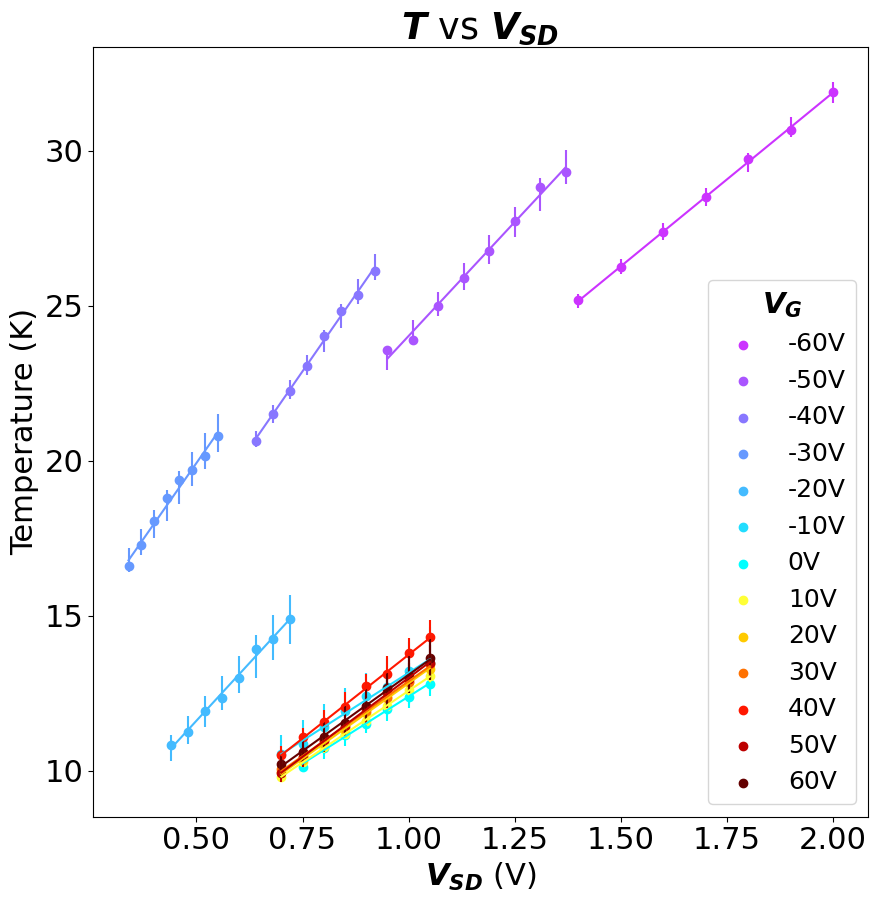

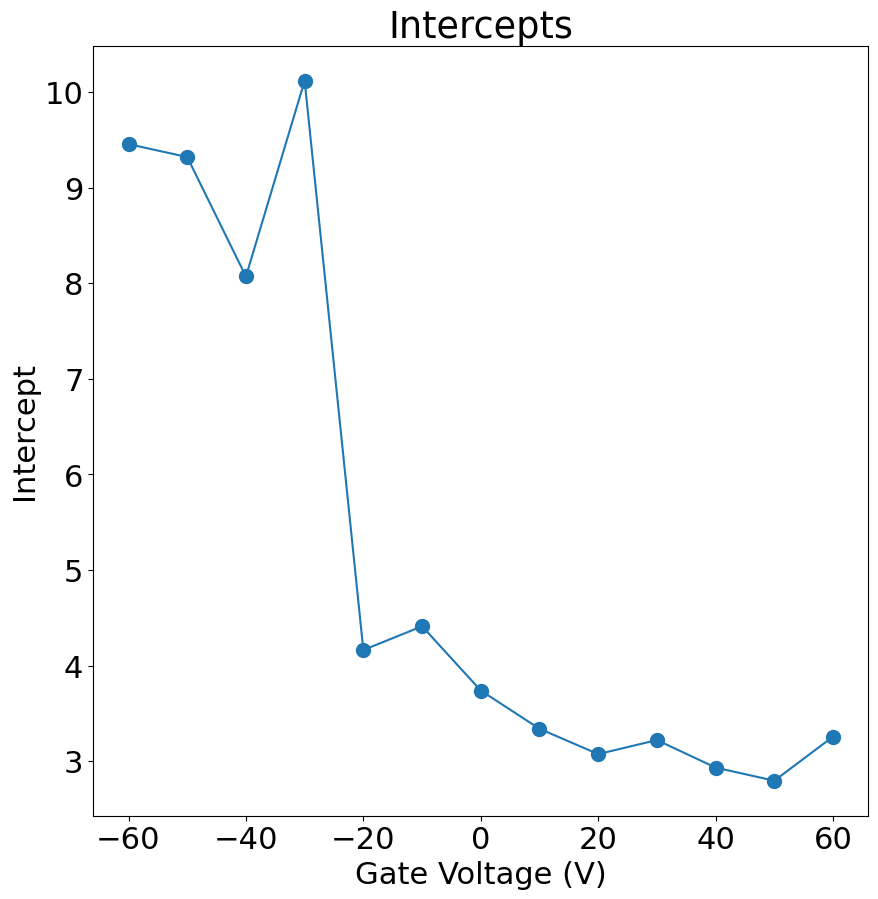

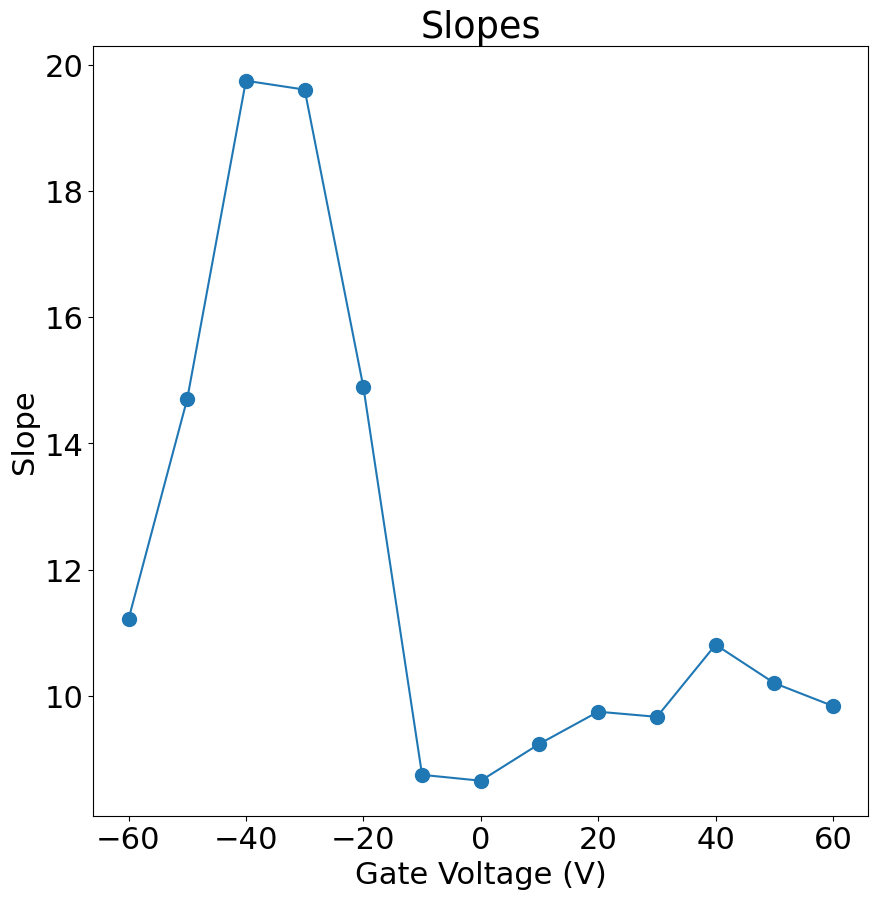

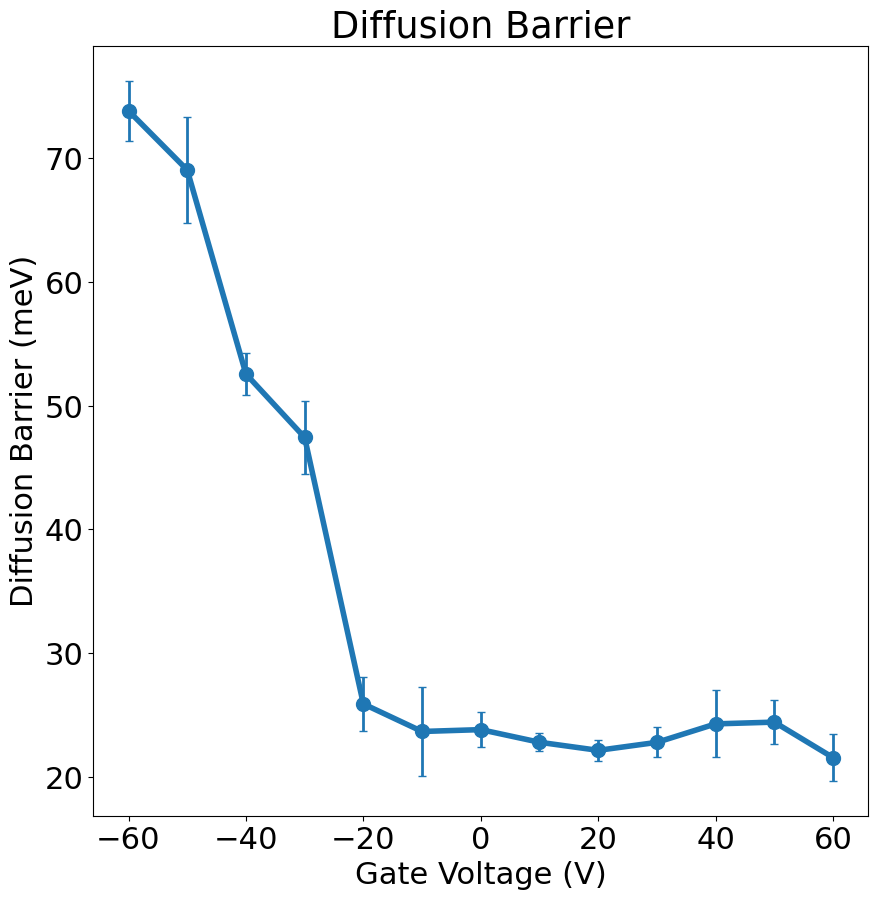

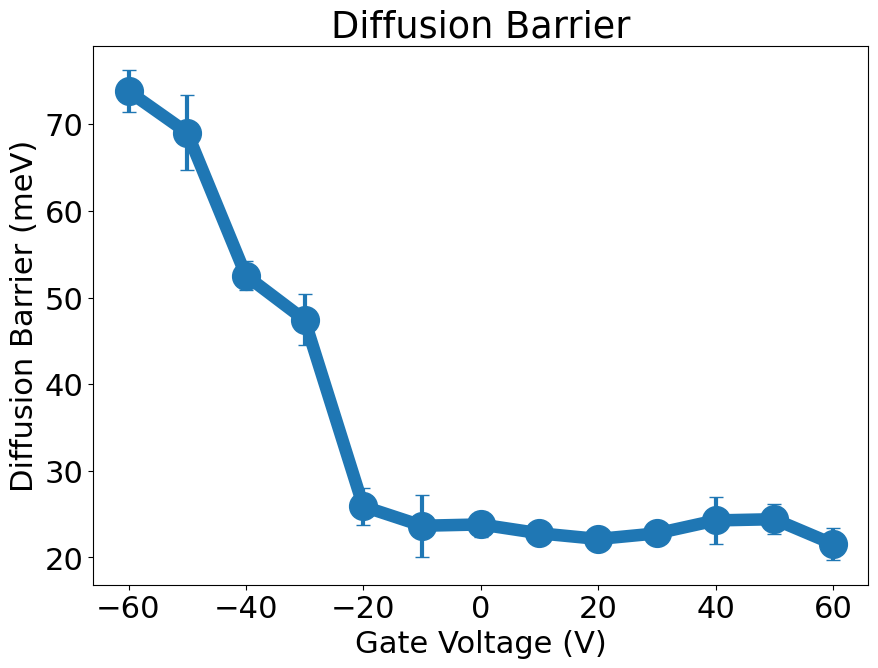

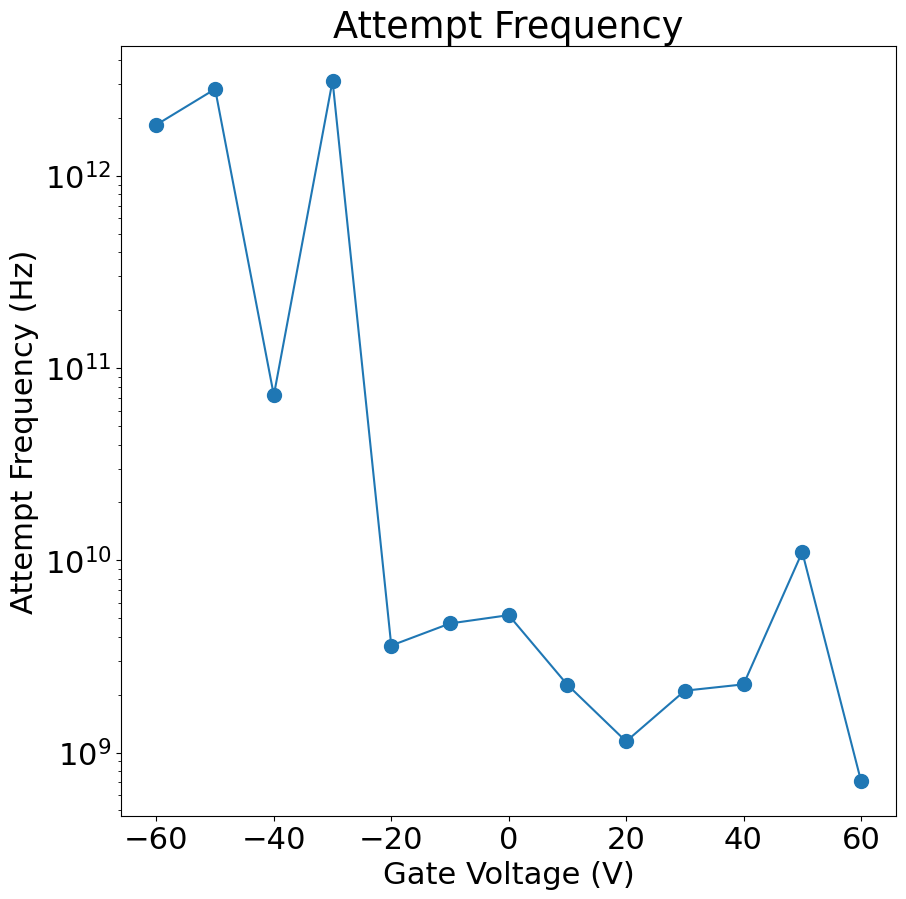

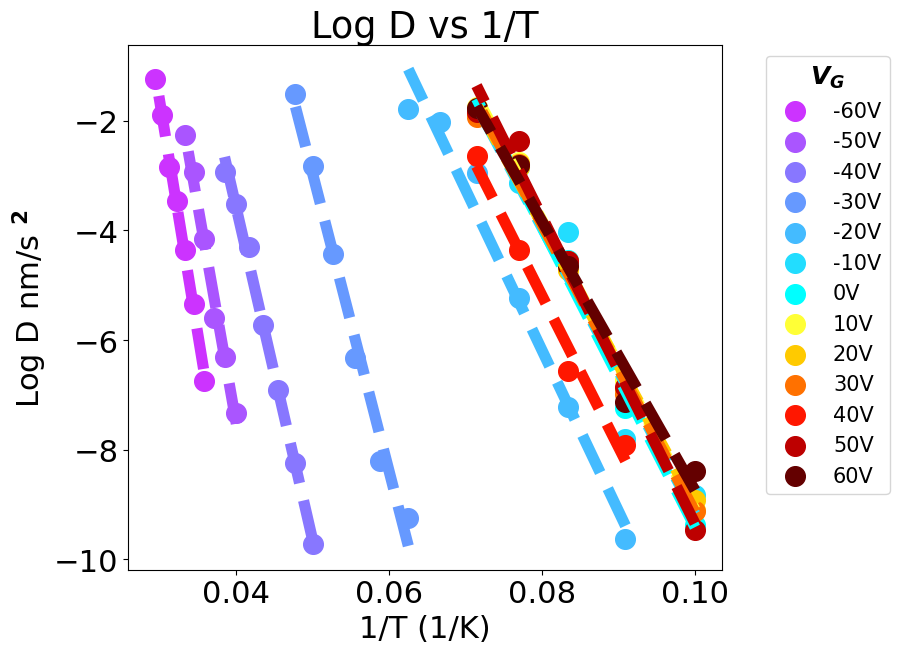

In [189]:
font = {'family': 'sans-serif','weight' : 'normal','size'   : 22}

mpl.rc('font', **font)
mpl.rc('text',usetex =False)
gates=np.arange(-60,70,10)
temps=[] #estimated temps
volts=[] #source drain voltages
stderror_invts=[] #std error in inverse ets temperatures 
errors_temp=[] #error in est temperatures
tmpvs=[] #heater temps
results=[] #linear fit for inv T vs log d
pars=[]
D_heaters=[]# diffusion of heater
D_sds=[] #diffusion source drain
for i,gate in enumerate(gates):
    (voltage,estimate_temps,std_error,
     error_temp,gate,tmpv,result,
     tempfit,D_heater,D_sd)=temp_volt_comp(gate,dps[i+13],dps[i])
    volts.append(voltage)
    temps.append(estimate_temps)
    tmpvs.append(tmpv)
    results.append(result) #
    errors_temp.append(error_temp)
    stderror_invts.append(std_error)
    D_heaters.append(D_heater)
    D_sds.append(D_sd)
plt.figure()
plt.title(r'$T$ vs $V_{SD}$ ')
plt.xlabel("$V_{SD}$ (V)")
plt.ylabel('Temperature (K)')
cmap = plt.cm.get_cmap("cool")
cmap2=plt.cm.get_cmap("hot")
colors = np.concatenate((cmap(np.linspace(0.8,0,7)),cmap2(np.linspace(0.8,0.0,7))))
for i,gate in enumerate(gates):
    x=volts
    y=temps
    plt.scatter(x[i],y[i],label=f'{gate}V',color=colors[i],marker='o')
    result=scipy.stats.linregress(x[i],y[i])
    plt.errorbar(x[i],result.slope*np.array(x[i])+result.intercept,yerr=errors_temp[i],color=colors[i])
    pars.append([result.slope,result.intercept])
plt.legend(title='$V_{G}$',fontsize=18,title_fontsize=21,loc='lower right')
plt.savefig('./Luc Folder/Heater_exp/Voltage_V_temp_all.svg')

plt.figure()
plt.plot(gates,[par[1] for par in pars],marker='o',markersize=10)
plt.title(r'Intercepts')
plt.xlabel(r'Gate Voltage (V)')
plt.ylabel('Intercept')
plt.savefig('./Luc Folder/Heater_exp/TempIntercept_vs_V.svg')

plt.figure()
plt.plot(gates,[par[0] for par in pars],marker='o',markersize=10)
plt.title(r'Slopes')
plt.xlabel(r'Gate Voltage (V)')
plt.ylabel('Slope')
plt.savefig('./Luc Folder/Heater_exp/TempSlope_vs_V.svg')

plt.figure()
plt.title("Diffusion Barrier")
plt.xlabel(r'Gate Voltage (V)')
plt.ylabel('Diffusion Barrier (meV)')
kb=8.617333262*10**-5 #eV K-1
x=gates
y=[-1/result.slope*kb*1000 for result in results]
barriers=y
yerr=[np.abs(1/result.slope-1/(result.slope+result.stderr))*kb*1000 for result in results]
plt.plot(x,y,marker='o',markersize=10,color='C0',linewidth=4)
plt.errorbar(x,y,yerr=yerr,color='C0',capsize=3,linewidth=2)
#squished
plt.figure(figsize=(10,7))
plt.title("Diffusion Barrier")
plt.xlabel(r'Gate Voltage (V)')
plt.ylabel('Diffusion Barrier (meV)')
kb=8.617333262*10**-5 #eV K-1
x=gates
y=[-1/result.slope*kb*1000 for result in results]
yerr=[np.abs(1/result.slope-1/(result.slope+result.stderr))*kb*1000 for result in results]
plt.plot(x,y,marker='o',markersize=20,color='C0',linewidth=9)
plt.errorbar(x,y,yerr=yerr,color='C0',capsize=5,linewidth=3)

plt.savefig('./Luc Folder/Heater_exp/Diffusion_barrier.svg')

plt.figure()
plt.title("Attempt Frequency")
plt.xlabel(r'Gate Voltage (V)')
plt.ylabel('Attempt Frequency (Hz)')
x=gates
y=[np.exp(-result.intercept/(result.slope))/(0.246)**2*4 for result in results]
plt.plot(x,y,marker='o',markersize=10)
plt.yscale('log')
plt.savefig('./Luc Folder/Heater_exp/Attempt_Frequency.svg')

plt.figure(figsize=(10,7))
plt.title(r"Log D vs 1/T")
plt.xlabel('1/T (1/K)')

plt.ylabel('Log D nm/s $^2$',fontweight='normal')
for i,gate in enumerate(gates):
    x=1/np.array(tmpvs[i])
    y=np.log(np.array((D_heaters[i])))
    plt.scatter(x,y,label=f'{gate}V',color=colors[i],marker='o',s=200)
    result=scipy.stats.linregress(x,y)
    plt.plot(x,result.slope*np.array(x)+result.intercept,
             color=colors[i],linestyle='--',linewidth=8)
    pars.append([result.slope,result.intercept])
plt.legend(title='$V_{G}$',fontsize=15,title_fontsize=18,loc='upper right',bbox_to_anchor=(1.3, 1))
plt.tight_layout()
plt.savefig('./Luc Folder/Heater_exp/All_logD_vs_Tinv.svg')


8.453381856495628e-05

In [229]:
np.arange(0,fit(x_2,*par)[-1],0.02)

array([0.  , 0.02, 0.04, 0.06, 0.08, 0.1 , 0.12, 0.14, 0.16, 0.18])

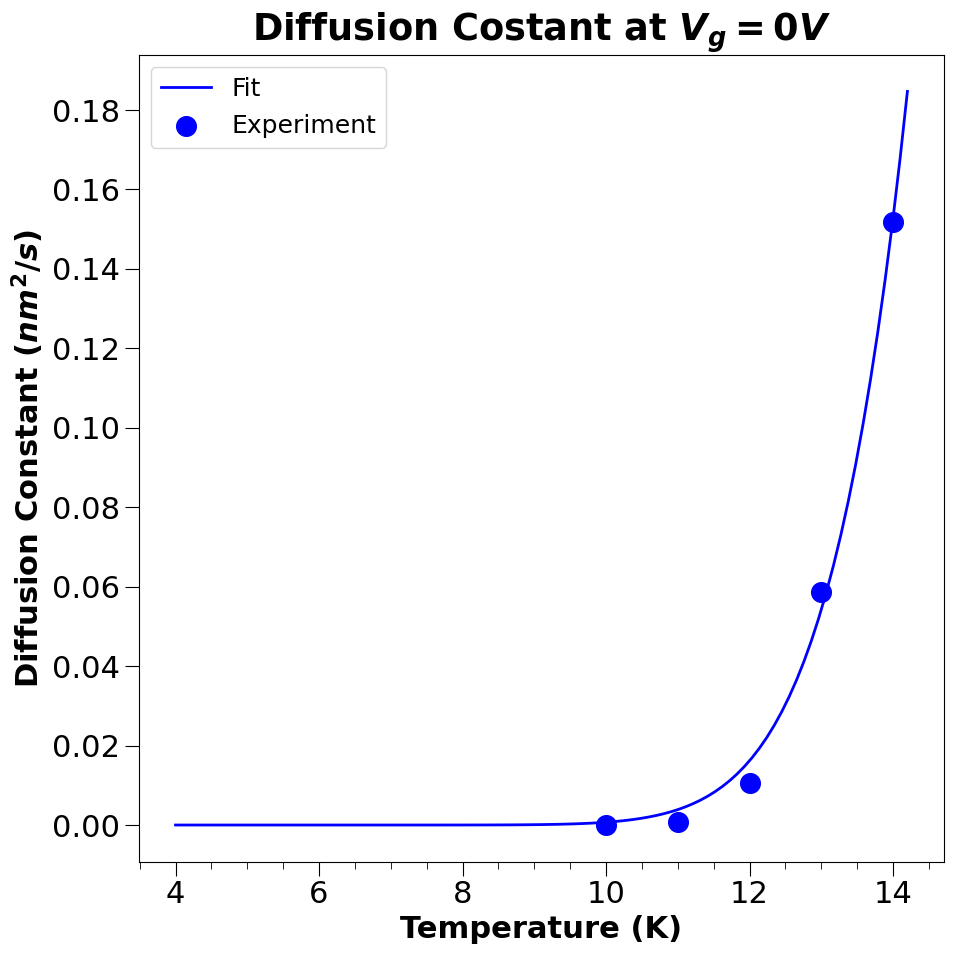

In [233]:
# Difusion vs temperuatre at 0V heater
x=np.array(tmpvs[6])[:]
y=np.array(D_heaters[6])[:]
plt.scatter(x,y,s=200,zorder=10,color='blue',label='Experiment')
fit=lambda x,a,b:a*np.exp(-b/x)
par,cov=curve_fit(fit,x,y,p0=(0.1,1),maxfev=1000)
x_=np.linspace(np.amin(x),np.amax(x),100)
x_2=np.linspace(4,14.2,100)
#plt.plot(x_,fit(x_,*par),color='blue',linewidth=4,)
plt.plot(x_2,fit(x_2,*par),color='blue',linewidth=2,zorder=0,
         label='Fit')
plt.legend(fontsize=18)
plt.minorticks_on()
plt.tick_params(axis='both', which='major', length=10)
plt.tick_params(axis='x', which='minor', length=5)

plt.tick_params(axis='y', which='minor', length=0)
plt.xlabel('Temperature (K)',fontweight='bold')
plt.yticks(np.arange(0,fit(x_2,*par)[-1],0.02))
plt.rcParams.update({'text.usetex': False})
plt.ylabel(r'Diffusion Constant ($nm^2/s$)',fontweight='bold')
plt.title('Diffusion Costant at $V_g = 0V$',fontweight='bold')
#plt.yscale('log')
plt.tight_layout()
plt.savefig('Diffusion_0V.png')

In [147]:
%%capture
for i,gate in enumerate(gates):
    fig1,fig2=temp_volt_comp(gate,dps[13+i],dps[i],start=1,plot=True)
    fig3,fig4=dps[i].plot_diffusion()
    fig5,fig6=dps[i+13].plot_diffusion();
    fig3.savefig(f'./Luc Folder/Heater_exp/{gate}V1_D_vs_V.svg')
    fig5.savefig(f'./Luc Folder/Heater_exp/{gate}V2_D_vs_T.svg')
    fig4.savefig(f'./Luc Folder/Heater_exp/{gate}V3_logD_vs_Vinv.svg')
    fig6.savefig(f'./Luc Folder/Heater_exp/{gate}V4_logD_vs_Tinv.svg')
    fig2.savefig(f'./Luc Folder/Heater_exp/{gate}V5_T_vs_V.svg')

                 
        

KeyboardInterrupt: 

In [147]:
from sxmreader import SXMReader
import trackpy as tp
from PIL import Image

In [148]:
self=ms[13]
t2s=[]

for i, path in enumerate(self.SXM_PATH):
            frames = SXMReader(path, correct=self.correct)
            #self.frames.append(frames)
            #self.NM_PER_PIXEL = frames.meters_per_pixel * 1e9 
            print(path)
            molecule_size, min_mass, max_mass, separation, min_size, max_ecc, adaptive_stop, search_range, _ = self.PARAMS[i]
            f = tp.batch(frames, molecule_size, minmass=min_mass, separation=separation,engine='python')
            t = tp.link(f, search_range=search_range, adaptive_stop=adaptive_stop,memory=7)
   
            t1 = t[((t['mass'] > min_mass) & (t['size'] > min_size) &
                 (t['ecc'] < max_ecc)) & (t['mass'] < max_mass)]
            t2 = tp.filter_stubs(t, 3)
            t2s.append(t2)
            # Compare the number of particles in the unfiltered and filtered data.
            print('Before:', t['particle'].nunique())
            print('After:', t2['particle'].nunique())


numbers=[208,209,210,211,212]
imgs=[]
for i in numbers:
    img = Image.open(f'./fig3 flattened images/Image_{i} Image Z (m)-2.jpg')
    img = img.resize((256, 256), Image.ANTIALIAS)
    img=img.convert('L')
    img = img.transpose(method=Image.FLIP_TOP_BOTTOM)
    imgs.append(img)


Frame 4: 26 trajectories present.
Before: 36
After: 27


/Users/lucnguyen/opt/anaconda3/envs/elmloc/lib/python3.7/site-packages/ipykernel_launcher.py:26: DeprecationWarning: ANTIALIAS is deprecated and will be removed in Pillow 10 (2023-07-01). Use LANCZOS or Resampling.LANCZOS instead.


NameError: name 't2s' is not defined

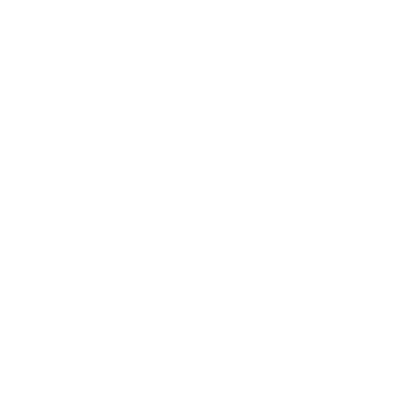

In [186]:
#
mpl.rcParams.update({'font.size': 10, 'font.weight':'bold'})
mpl.rc('image', origin='lower')
mpl.rc('text',usetex =False)
mpl.rc('text',color='black')
i=-2
frames=ms[13].frames[i]
for j, frame in enumerate(frames):
    b=plt.figure(figsize=(5,5))
    plt.axis('off')
    a=tp.plot_traj(t2s[i][(t2s[i]['frame']<=j)], superimpose=np.array(imgs[j]), 
                   label=False, origin='lower',plot_style={'color':'gray','linewidth':2.5})
    #a.invert_yaxis()
    plt.axis('off')
    b.savefig(f'./Luc Folder/fig1_{j}.svg')
                

/Users/lucnguyen/Desktop/URAP CROMMIE STUFF/molecule_tracking-master/analysis_stm.py:780: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['rotated'][test['dr']<0.04]=2
/Users/lucnguyen/opt/anaconda3/envs/elmloc/lib/python3.7/site-packages/seaborn/axisgrid.py:848: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  func(*plot_args, **plot_kwargs)
/Users/lucnguyen/opt/anaconda3/envs/elmloc/lib/python3.7/site-packages/seaborn/axisgrid.py:848: UserWarning: The sizes list has more values (3) than needed (2), which may not be intended.
  func(*plot_args, **plot_kwargs)
/Users/lucnguyen/opt/anaconda3/envs/elmloc/lib/python3.7/site-packages/seaborn/axisgrid.py:848: UserWarning: The markers list has more values (3) than needed (2), which may not be intended.
  func

KeyError: 2

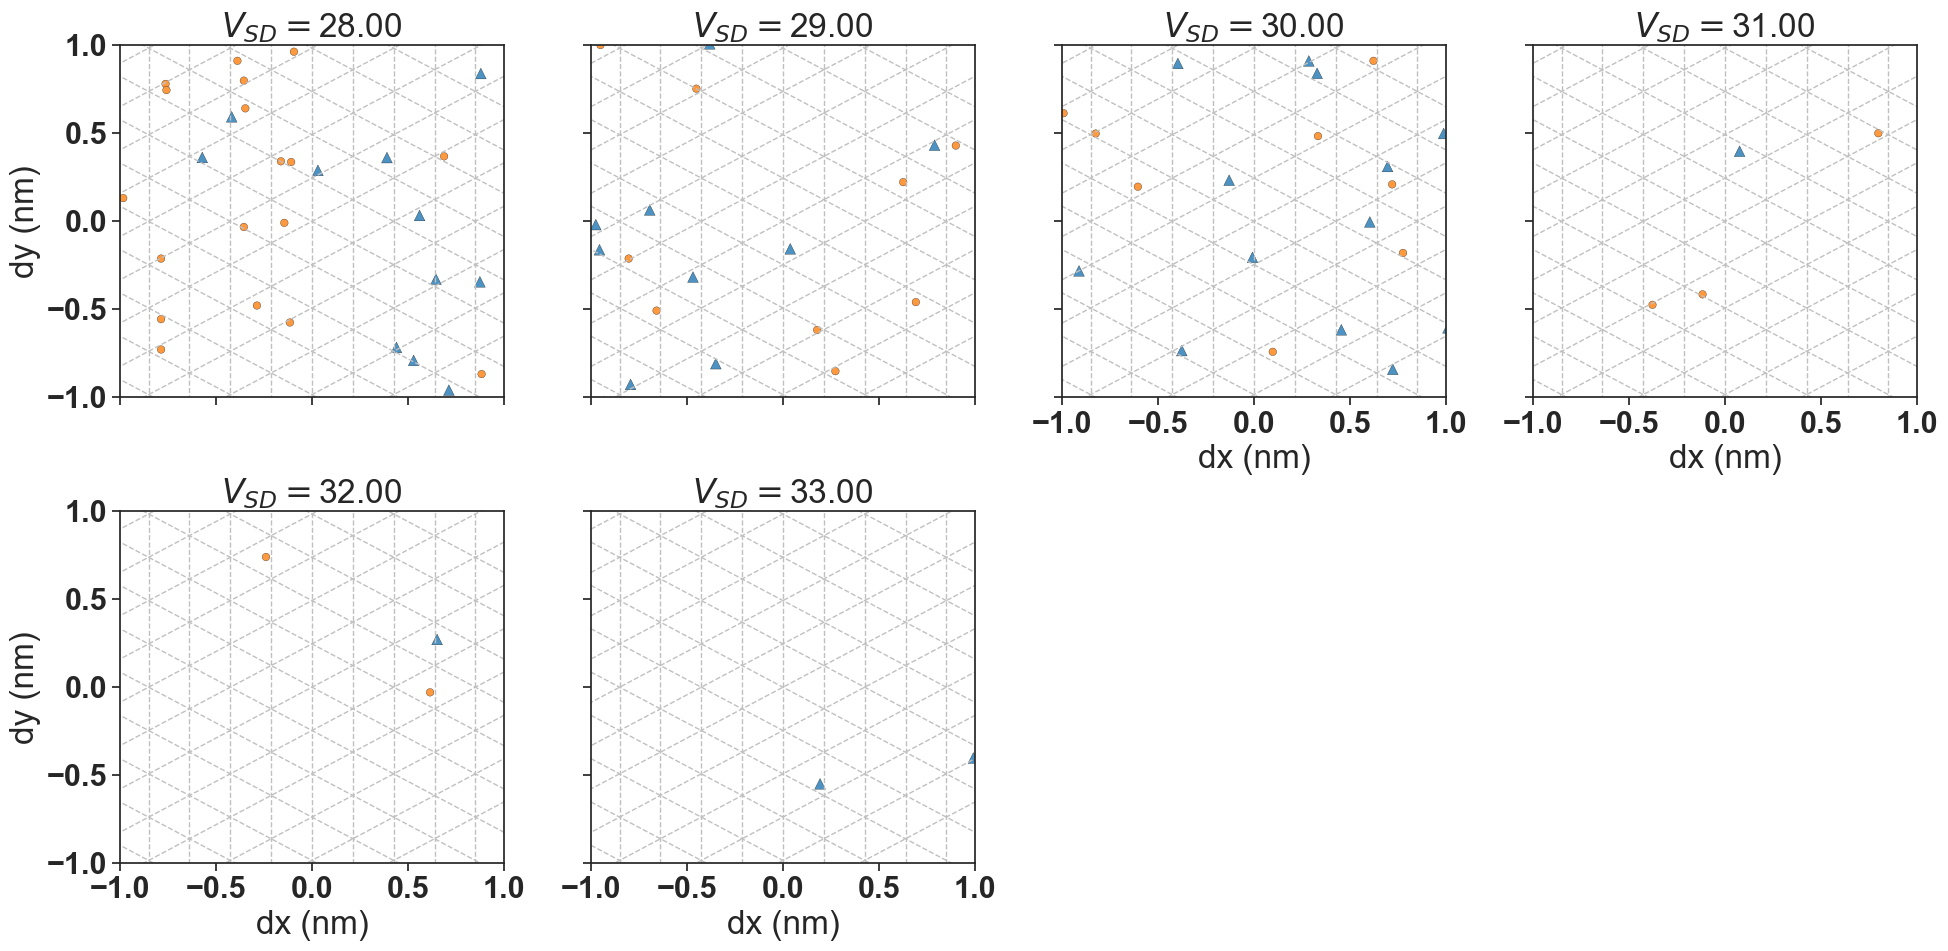

In [215]:
dp_test=DiffusionPlotter(ms[13])
dp_test.plot_scatter_rot()

/Users/lucnguyen/opt/anaconda3/envs/elmloc/lib/python3.7/site-packages/ipykernel_launcher.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/Users/lucnguyen/opt/anaconda3/envs/elmloc/lib/python3.7/site-packages/seaborn/axisgrid.py:848: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  func(*plot_args, **plot_kwargs)
/Users/lucnguyen/opt/anaconda3/envs/elmloc/lib/python3.7/site-packages/seaborn/axisgrid.py:848: UserWarning: The sizes list has more values (3) than needed (2), which may not be intended.
  func(*plot_args, **plot_kwargs)
/Users/lucnguyen/opt/anaconda3/envs/elmloc/lib/python3.7/site-packages/seaborn/axisgrid.py:848: UserWarning: The markers list has more values (3) than needed (2), which may not be intended.
  func(*plot_args, **plot_kwargs)


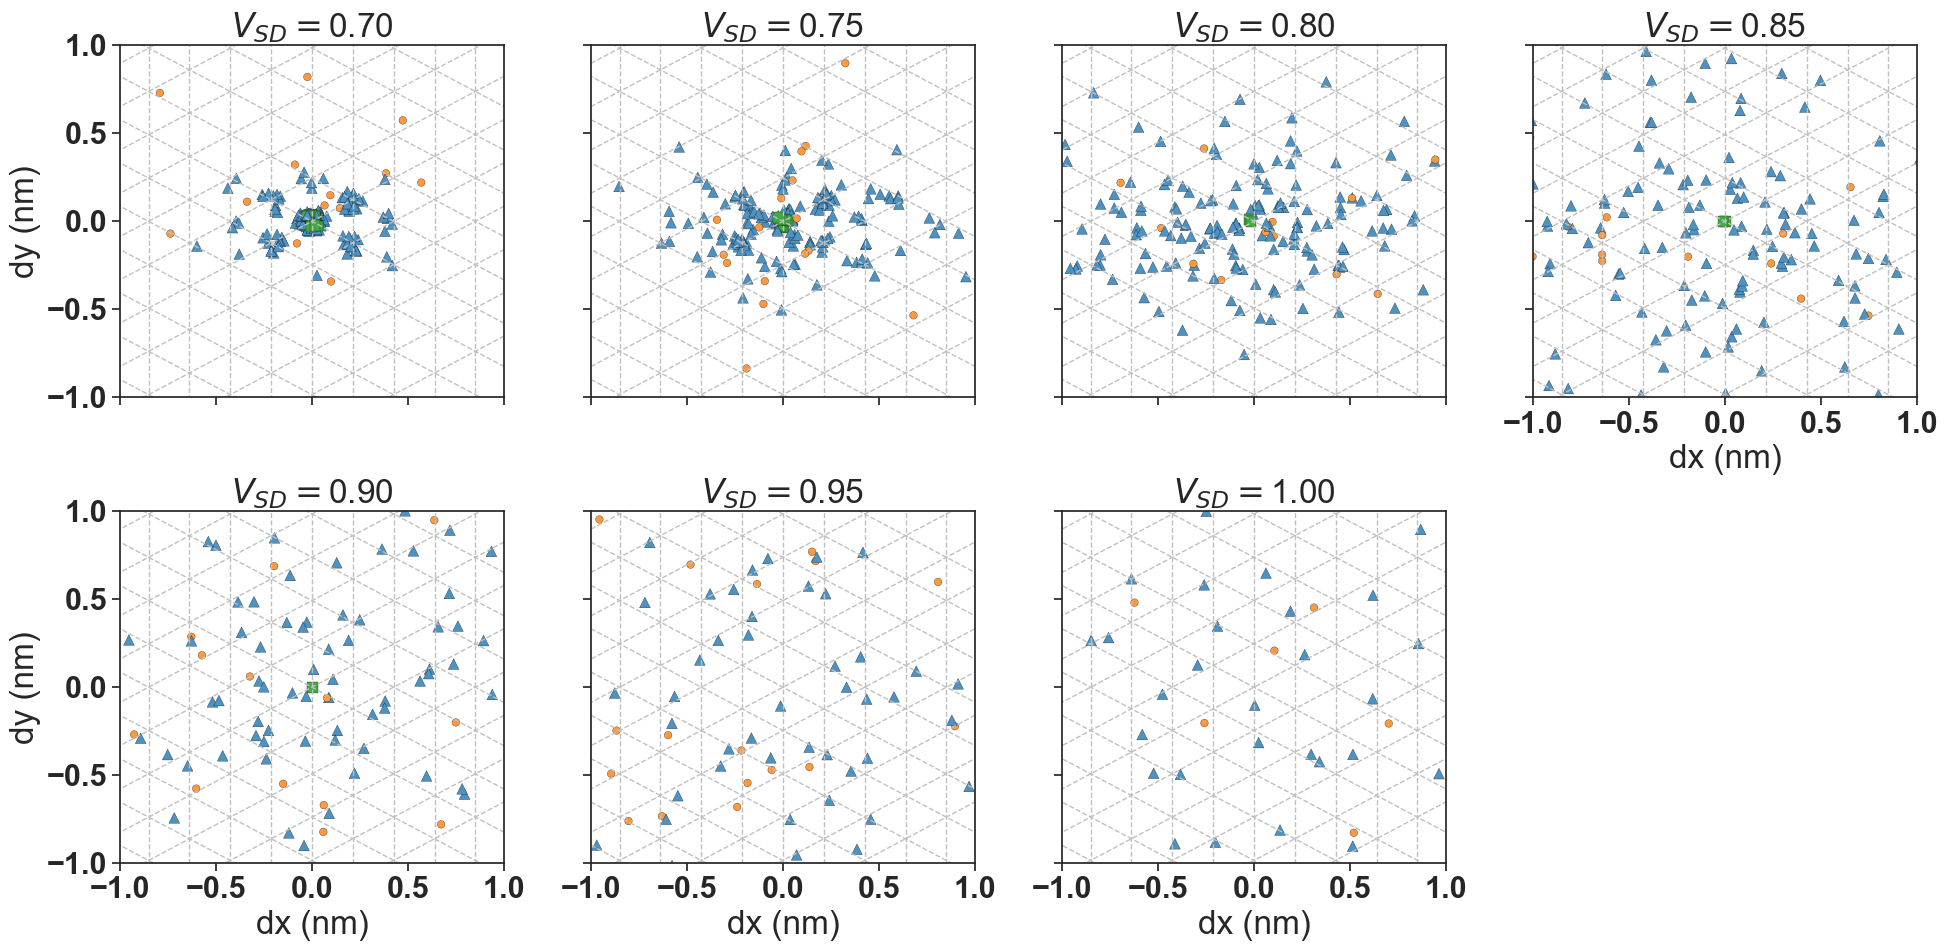

In [180]:
import seaborn as sns
import pandas as pd
test=plot_scatter_rot(dps[12])

In [166]:
ms[0].CorrectDrift(False)
ms[13].CorrectDrift(False)
dp_rot=[DiffusionPlotter(ms[0]),DiffusionPlotter(ms[13])]

/Users/lucnguyen/Desktop/URAP CROMMIE STUFF/molecule_tracking-master/analysis_stm.py:423: RuntimeWarning: invalid value encountered in reciprocal
  result = linregress(np.reciprocal(tmpv), np.log(_sorted_D_constants))
/Users/lucnguyen/Desktop/URAP CROMMIE STUFF/molecule_tracking-master/analysis_stm.py:424: RuntimeWarning: invalid value encountered in reciprocal
  result2 = linregress(np.reciprocal(tmpv), np.log(_sorted_D_constants2))
/Users/lucnguyen/Desktop/URAP CROMMIE STUFF/molecule_tracking-master/analysis_stm.py:424: RuntimeWarning: invalid value encountered in log
  result2 = linregress(np.reciprocal(tmpv), np.log(_sorted_D_constants2))


/Users/lucnguyen/Desktop/URAP CROMMIE STUFF/molecule_tracking-master/analysis_stm.py:780: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['rotated'][test['dr']<0.04]=2
/Users/lucnguyen/Desktop/URAP CROMMIE STUFF/molecule_tracking-master/analysis_stm.py:780: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['rotated'][test['dr']<0.04]=2
/Users/lucnguyen/opt/anaconda3/envs/elmloc/lib/python3.7/site-packages/seaborn/axisgrid.py:848: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  func(*plot_args, **plot_kwargs)
/Users/lucnguyen/opt/anaconda3/envs/elmloc/lib/python3.7/sit

ValueError: operands could not be broadcast together with shapes (6,) (0,) 

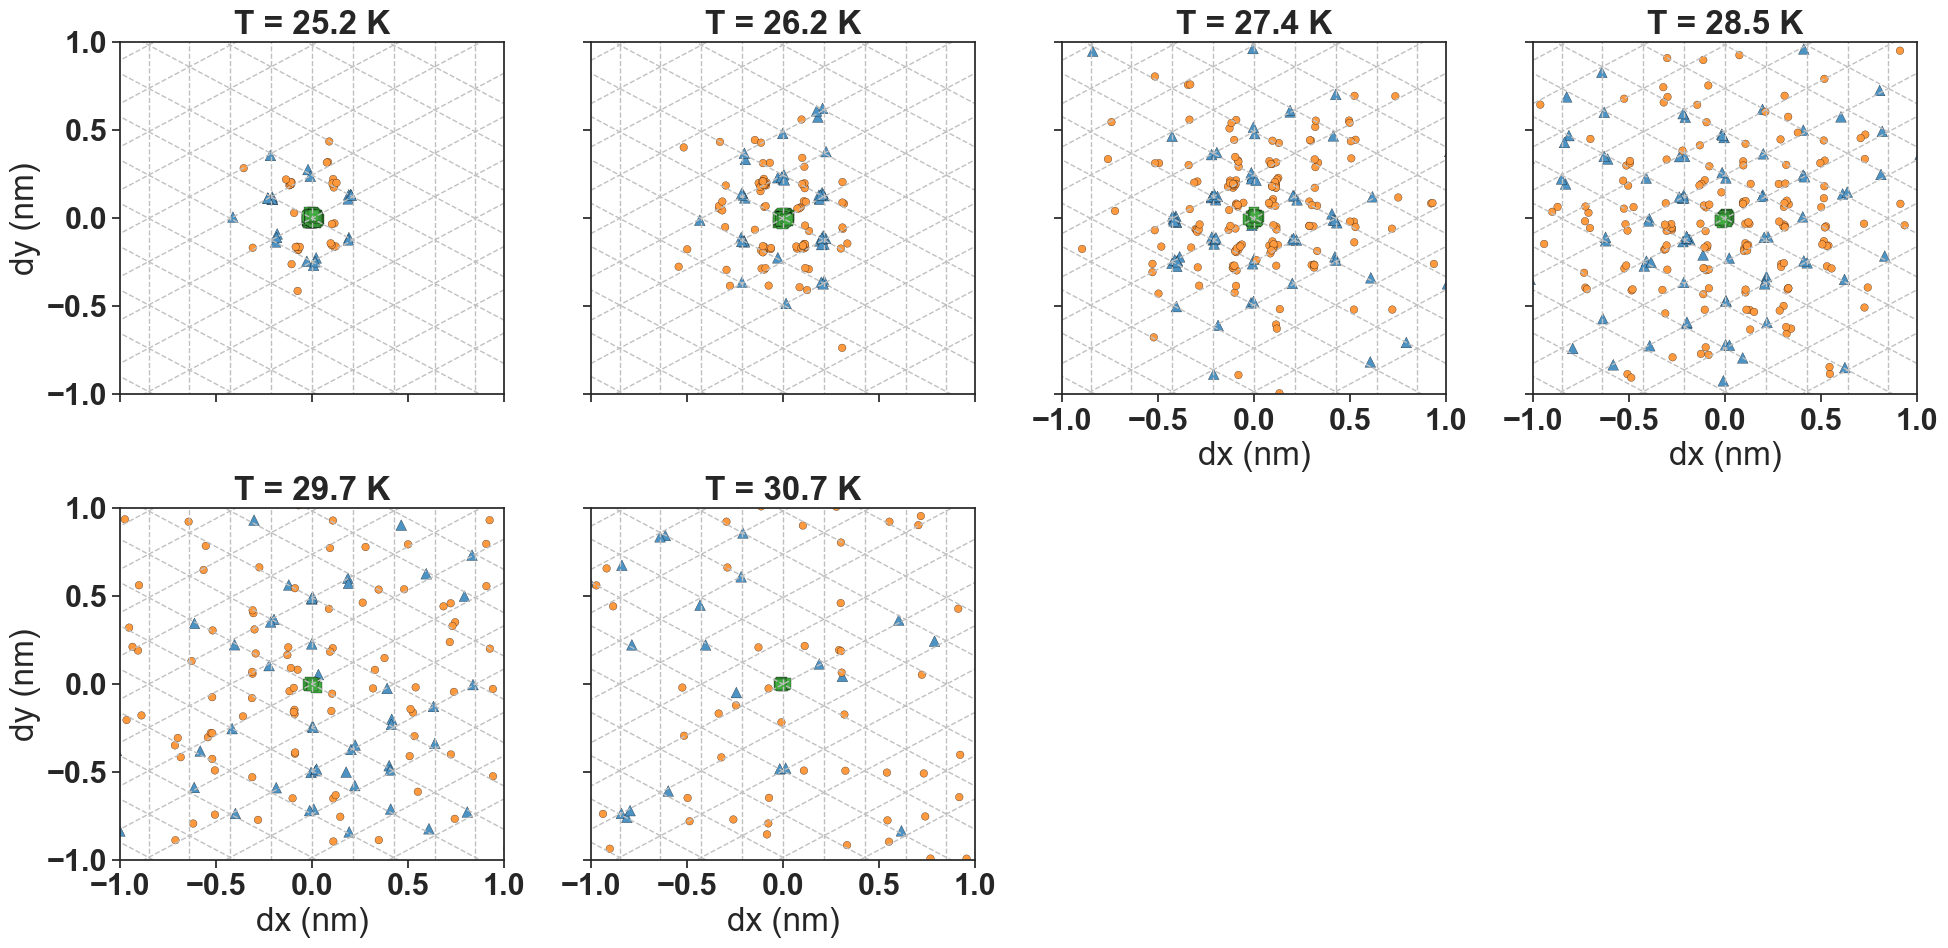

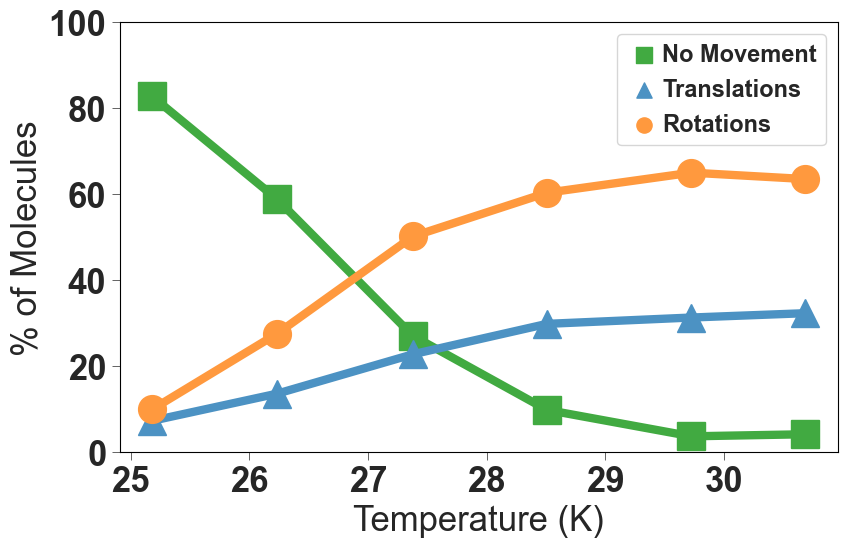

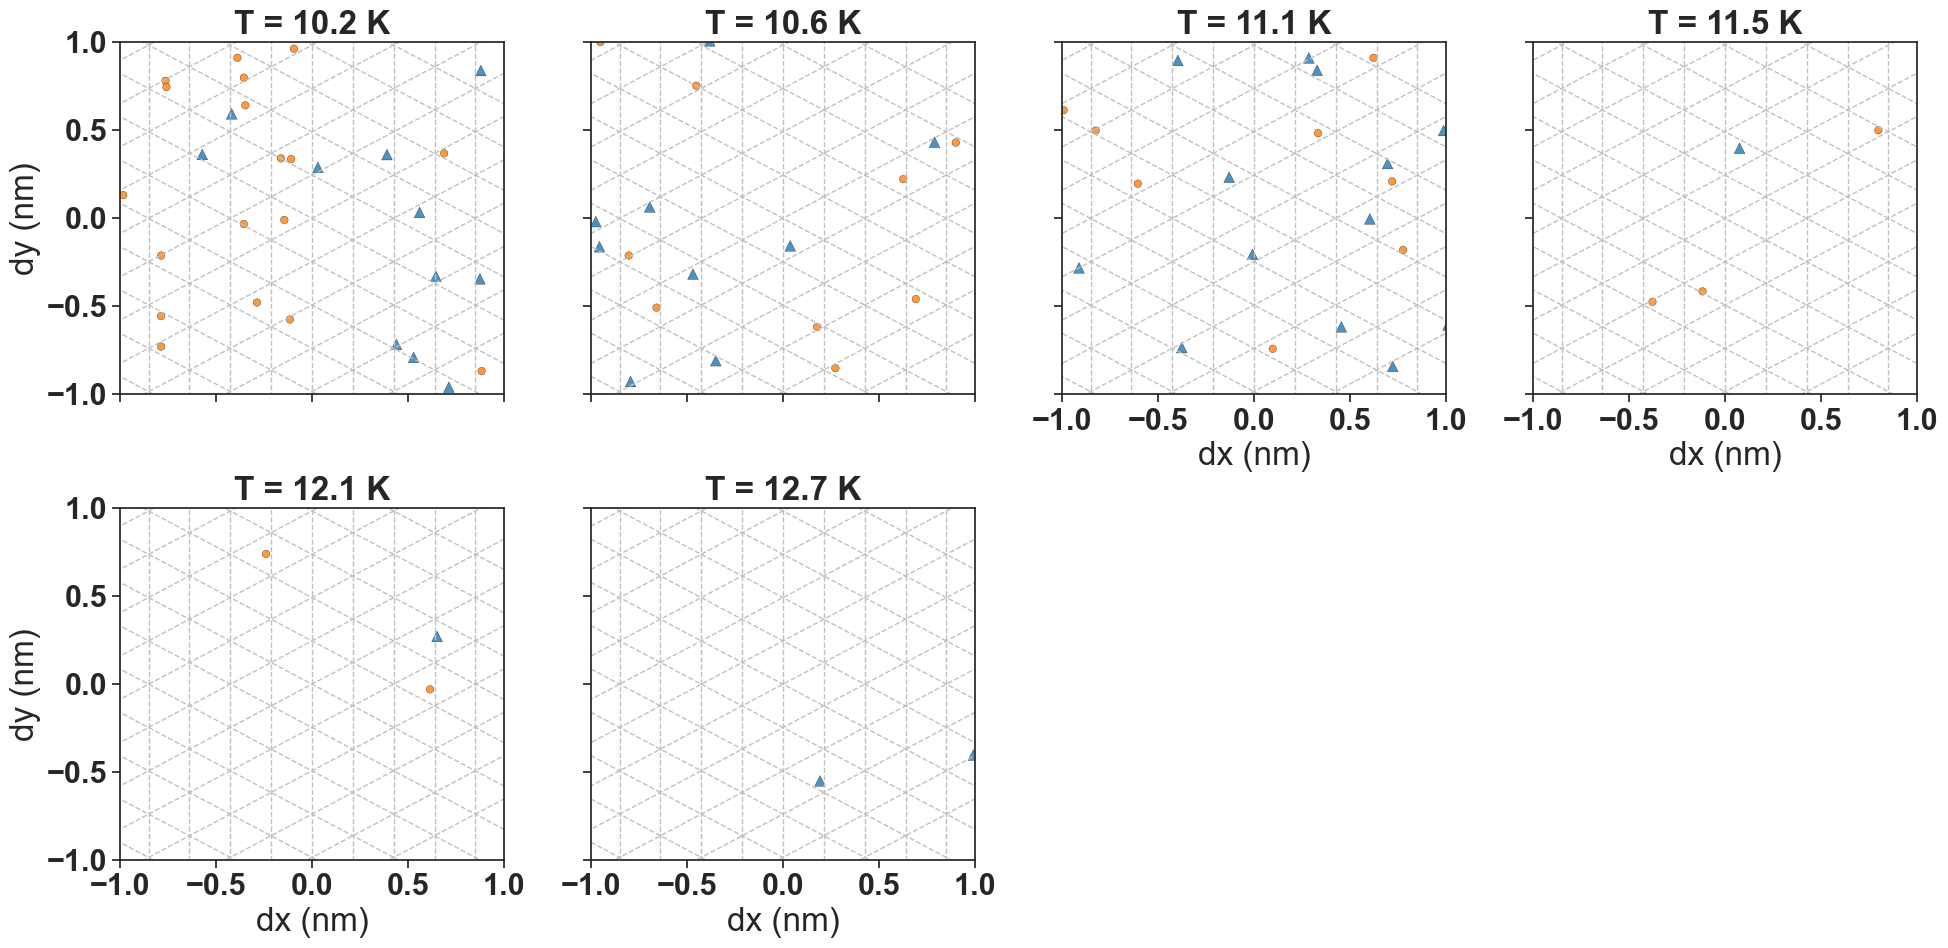

In [158]:

for i in range(2):
    index=[0,12][i]
    stuff=temp_volt_comp(gate,dps[index+13],dps[index])
    estimated_temps=stuff[1]
    titles=[f'T = {temp:.1f} K' for temp in estimated_temps]
    dp_rot[i].plot_scatter_rot(titles=titles,temps=estimated_temps[:-1])


In [ ]:
#optional change normal to bold
font = {'family' : 'normal','weight' : 'normal','size'   : 20}
plt.rc('font', **font)
dp.plot_drift_vectors(color1='Blues',color2='PuRd',range1=(0.2,0.8),range2=(0.2,0.7))
plt.savefig('./Luc Folder/DriftVectorsBoth4.svg', format='svg')

In [244]:
from PIL import Image
img = Image.open('./Luc Folder/Image_804 Image Z (m).jpgImage_804 Image Z (m).jpg')
img = img.resize((192, 192))
img=img.convert('L')
img = img.transpose(method=Image.FLIP_TOP_BOTTOM)
from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors


def plot_rocket_tracks(self, set_i=-1, image_i = -1, valid_list = [], label_particles = False,custom_image=False):
    x_end = self.t3s[set_i].groupby(by='particle').x.apply(list)
    y_end = self.t3s[set_i].groupby(by='particle').y.apply(list)

    if not valid_list:
        valid_list = list(x_end.index)
        valid_list.remove(23)
        valid_list.remove(0)
        valid_list.remove(1)

        valid_list.remove(16)


        #valid_list = [2,24,8,12,19,22,7,6,5,9,13,10,1,21,16] # positive current
        #valid_list = [17,20,15,0,16,10,19,21,9,12,8,7,6,11] # negative current
    fig, ax = plt.subplots(figsize=(10,10))
    skip = 1
    for i in valid_list:
        if not custom_image:
            ax.imshow(self.frames[set_i][image_i],cmap='gray')
        else:
            ax.imshow(custom_image,cmap='gray')
        
        ax.set_xlim(-0.5, (self.frames[set_i][image_i].shape[1] - 0.5))
        ax.set_ylim(-0.5, (self.frames[set_i][image_i].shape[0] - 0.5))
        #x_plt=x_end[i]
        #y_plt=y_end[i]
        x_plt =x_end[i]# self._avg_over_n_steps(x_end[i], skip)
        y_plt =y_end[i] #self._avg_over_n_steps(y_end[i], skip)
        cmap = plt.cm.get_cmap("YlOrRd")
        colors = cmap(np.linspace(0.8,0.0,len(x_plt)+1))
        length=(np.size(x_plt[:image_i]))
        if label_particles:
            ax.text(x_plt[image_i],y_plt[image_i],f'{i} ')

            #ax.text(x_plt[image_i],y_plt[image_i],f'{i} ({x_plt[image_i]:.1f},{y_plt[image_i]:.1f})')
        for j in range(length):
            plot=ax.plot(x_plt[j:j+2], y_plt[j:j+2], color=colors[j], linewidth=3,)
    #if j==math.floor(length/4) or j==math.ceil(2*length/3):
                #plt.arrow((x_plt[j+1]+x_plt[j])/2,(y_plt[j+1]+y_plt[j])/2,(x_plt[j+1]-x_plt[j])/5, (y_plt[j+1]-y_plt[j])/5,color=colors[j],head_width=4,
                          #head_length=3,overhang=0.5,length_includes_head=True,zorder=5)
        #ax.scatter(x_plt[0], y_plt[0], color='white',marker='x', s=60,zorder=5)

    #ax.axis('off')
    cmap = mcolors.ListedColormap(colors)
    norm = mcolors.BoundaryNorm(np.arange(len(colors) + 1), cmap.N)
    cbar = plt.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax, ticks=np.arange(len(colors)) + 0.5,shrink=0.8)
    cbar.set_ticklabels([str(j) for j in range(len(colors))])
    return fig

a=plot_rocket_tracks(dp2,set_i=1,image_i =-2,label_particles=False,custom_image=img)
a.savefig('./Luc Folder/rockettracks_804.svg')


NameError: name 'dp2' is not defined

In [48]:
from matplotlib.ticker import MultipleLocator


In [149]:
def plot_diffusion(heater_dp,s_d_dp,Gate, suppress_output=False,fit_scat=False):
    (voltage,estimate_temps,std_error,error,gate,tmpv,result,tempfit,D_heater,D_sd)=temp_volt_comp(Gate,heater_dp,s_d_dp)
    fig, ax1 = plt.subplots(figsize=(10,10))
    plt.tick_params(axis='both', which='major', length=10)
    #plt.gca().xaxis.set_minor_locator(MultipleLocator(0.5))
    plt.tick_params(axis='both', which='minor', length=5)
   # plt.gca().yaxis.set_minor_locator(MultipleLocator(0.01))

    plt.minorticks_on()


    ax1.scatter(tmpv, D_heater, label='Remote Heating', color='C0',s=300)
    par,cov=curve_fit(lambda x,a,b:a*np.exp(-b/x),tmpv,D_heater)
    x=np.linspace(np.min(tmpv),np.max(tmpv),100)
    y=par[0]*np.exp(-par[1]/x)

    x2=np.linspace(np.min(estimate_temps),np.max(estimate_temps),100)
    y2=par[0]*np.exp(-par[1]/x2)
    ax1.plot(x,y,linewidth=6,zorder=0)
    ax1.plot(x2,y2,'--',color='C0',linewidth=6,zorder=0)
    fit_temps=-par[1]/np.log(D_sd/par[0])
    if fit_scat:
        ax1.scatter(fit_temps, D_sd, label='Direct Heating', color='r',s=250)
    else:
        ax1.scatter(estimate_temps, D_sd, label='Direct Heating', color='r',s=300,marker='s')
       # ax1.errorbar(estimate_temps, D_sd,xerr=error/1.96,color='r',linestyle='none',linewidth=3,capsize=5)
    ax1.set_xlabel('Temperature (K)',fontsize=30)
    ax1.set_ylabel(r'Diffusion Constant $(nm^2/s)$',fontsize=30)

    ax2 = ax1.twiny()
    ax2.set_xlabel("$V_{SD}$ (V)",fontsize=30,labelpad=20)

    ax2.set_xlim(ax1.get_xlim())
    if fit_scat:
        ax2.set_xticks(fit_temps)
    else:
        ax2.set_xticks(estimate_temps)
    labels=[f'{volt:.2f}' for volt in voltage]
    for i in range(len(labels)):
        if (i+1)%2==0:
            labels[i]=''
    ax2.set_xticklabels(labels)
    plt.tick_params(axis='both', which='major', length=10)
    #ax2.set_xticklabels(voltage, rotation=0, fontsize=8) 
    ax1.legend(loc='upper left')
    #ax2.legend(loc='upper right')
    plt.tight_layout()
    return(fig,fit_temps)

/Users/lucnguyen/opt/anaconda3/envs/elmloc/lib/python3.7/site-packages/ipykernel_launcher.py:11: RuntimeWarning: invalid value encountered in reciprocal
  # This is added back by InteractiveShellApp.init_path()


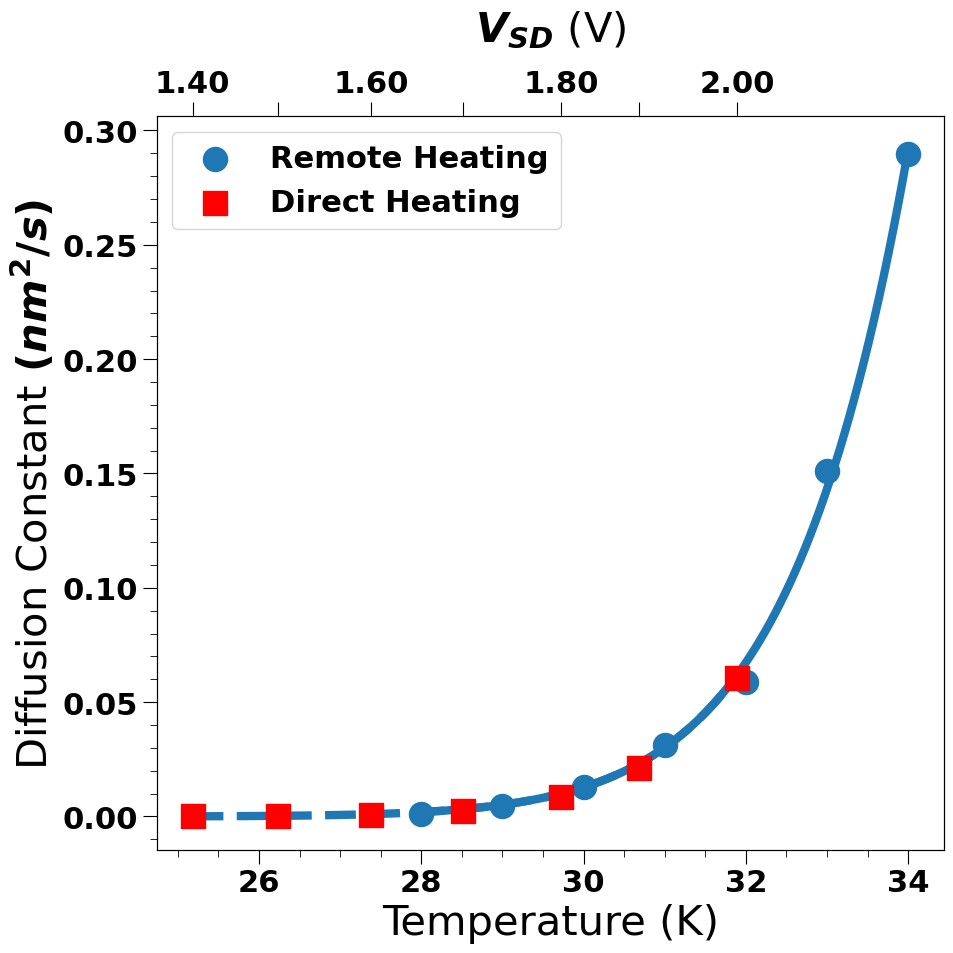

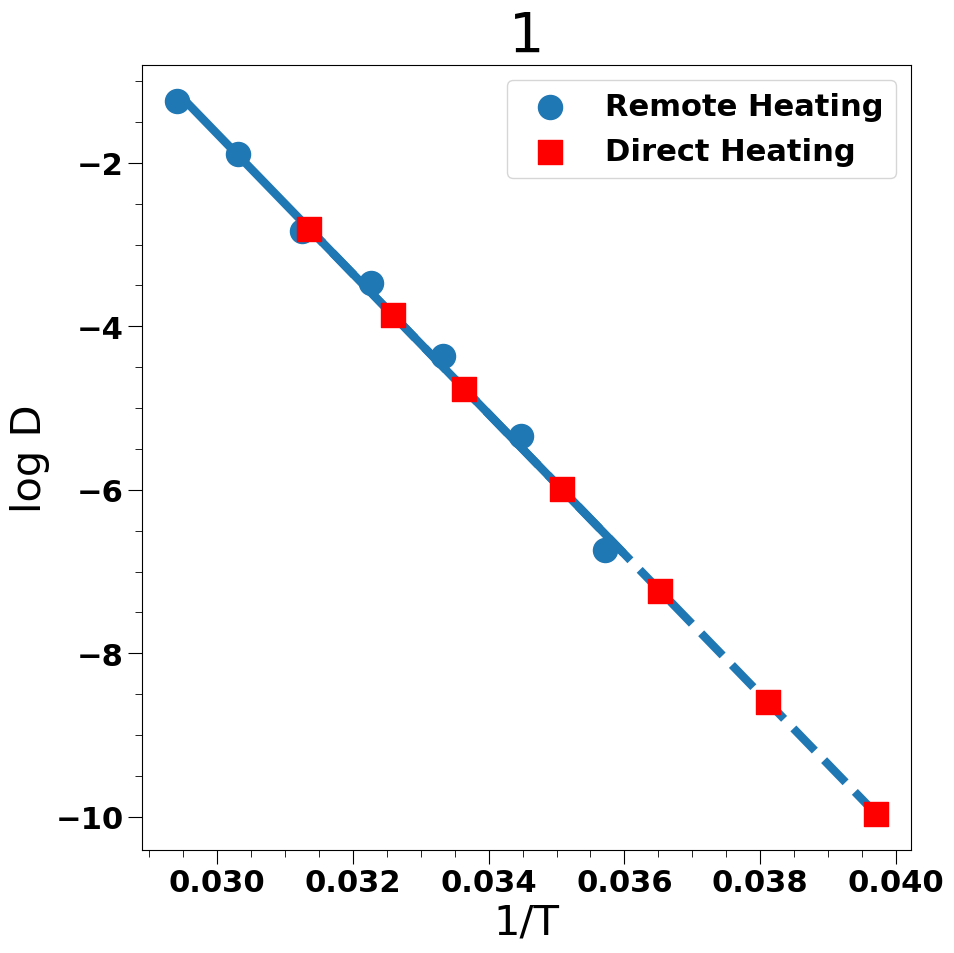

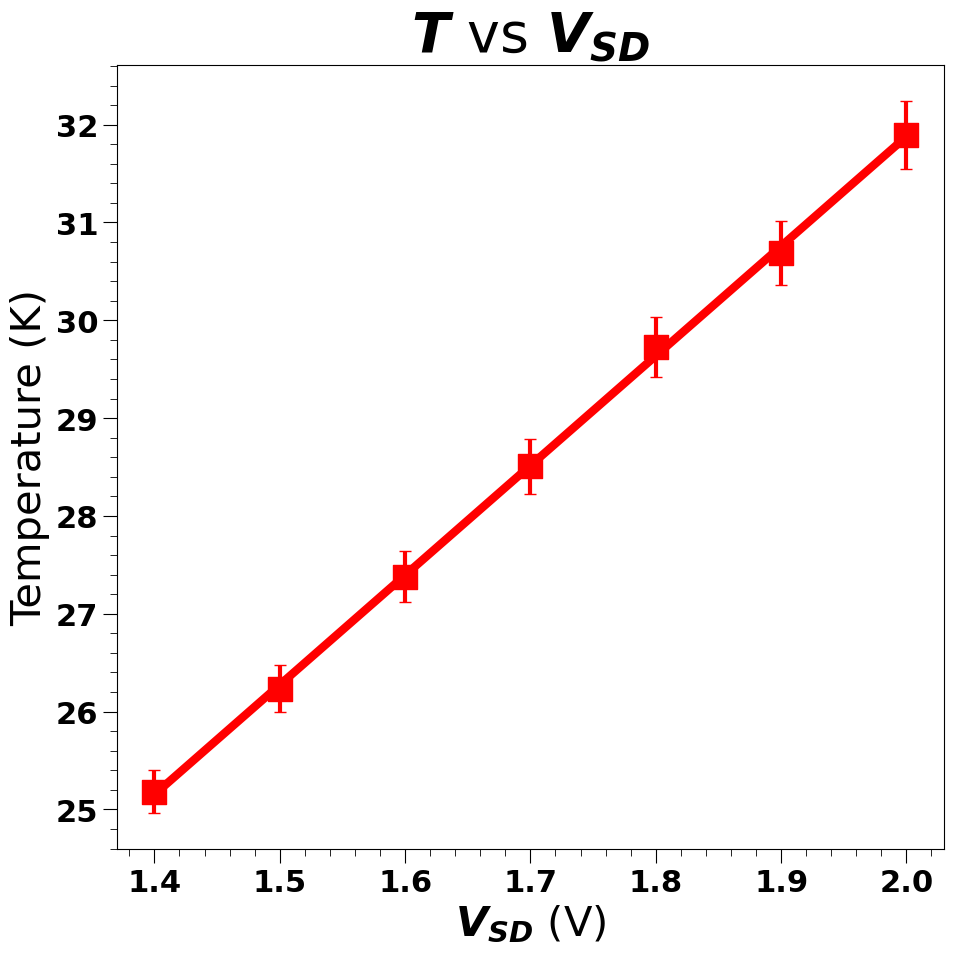

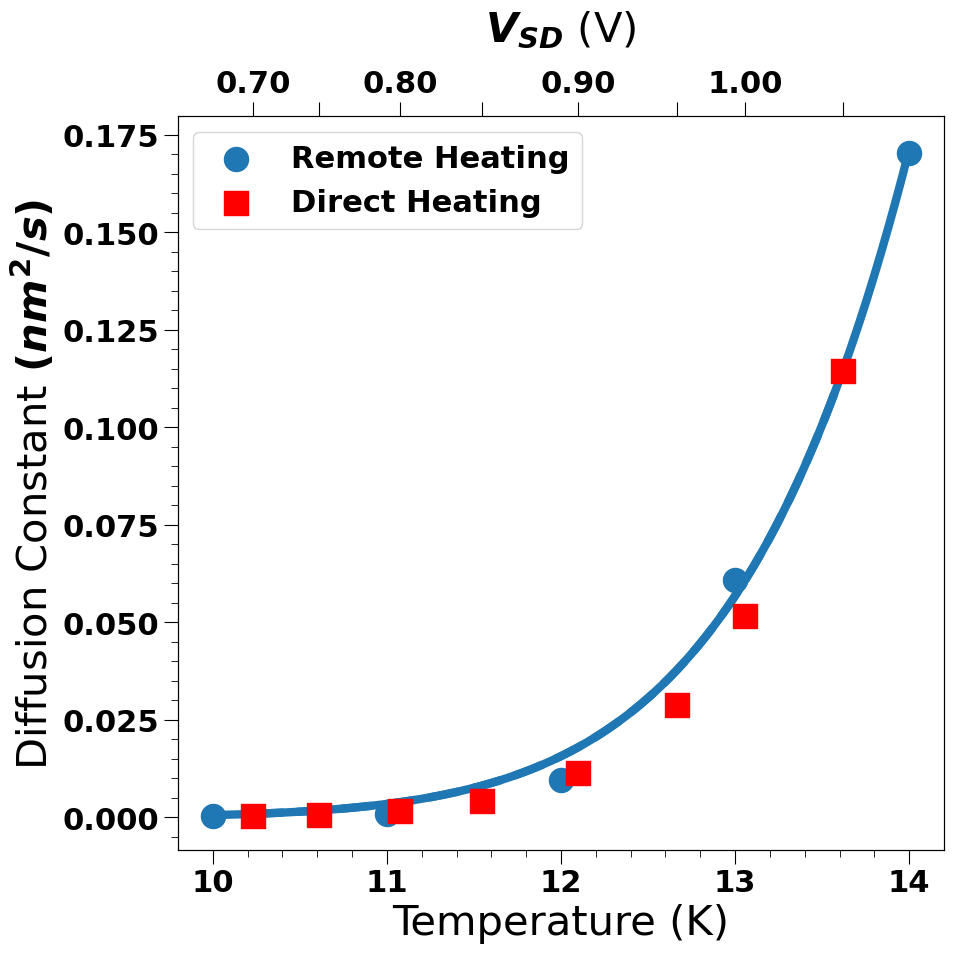

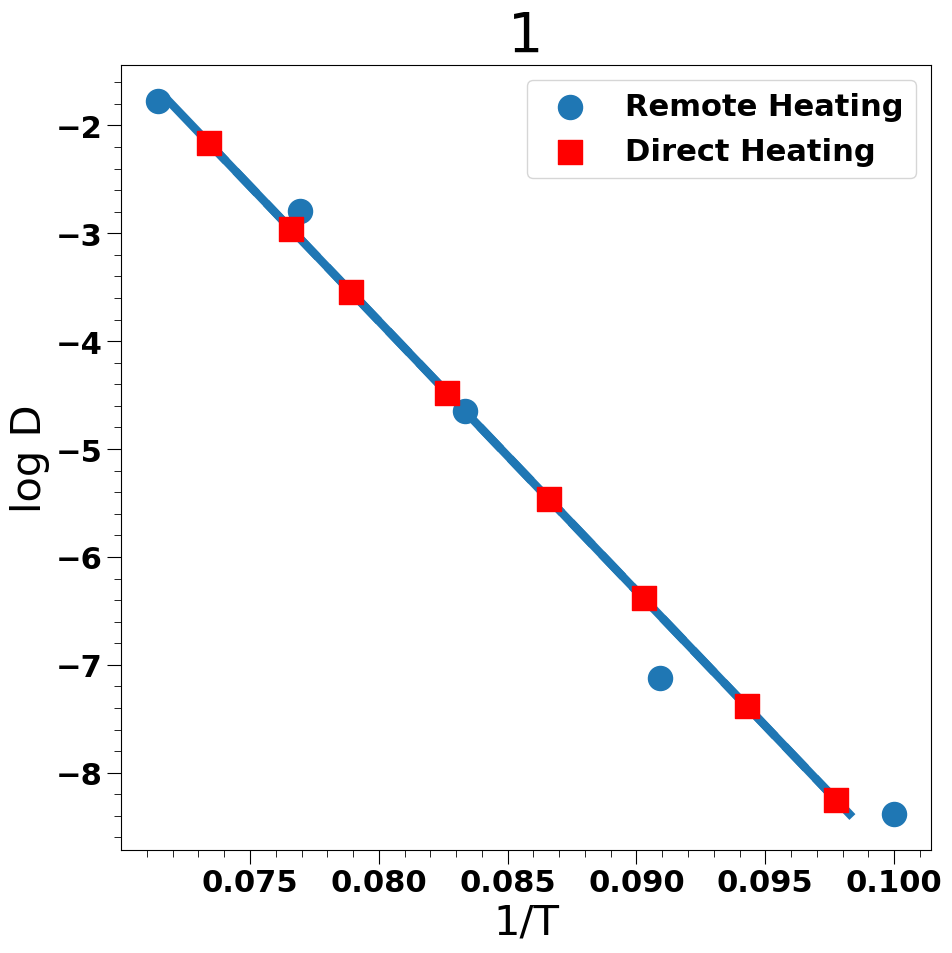

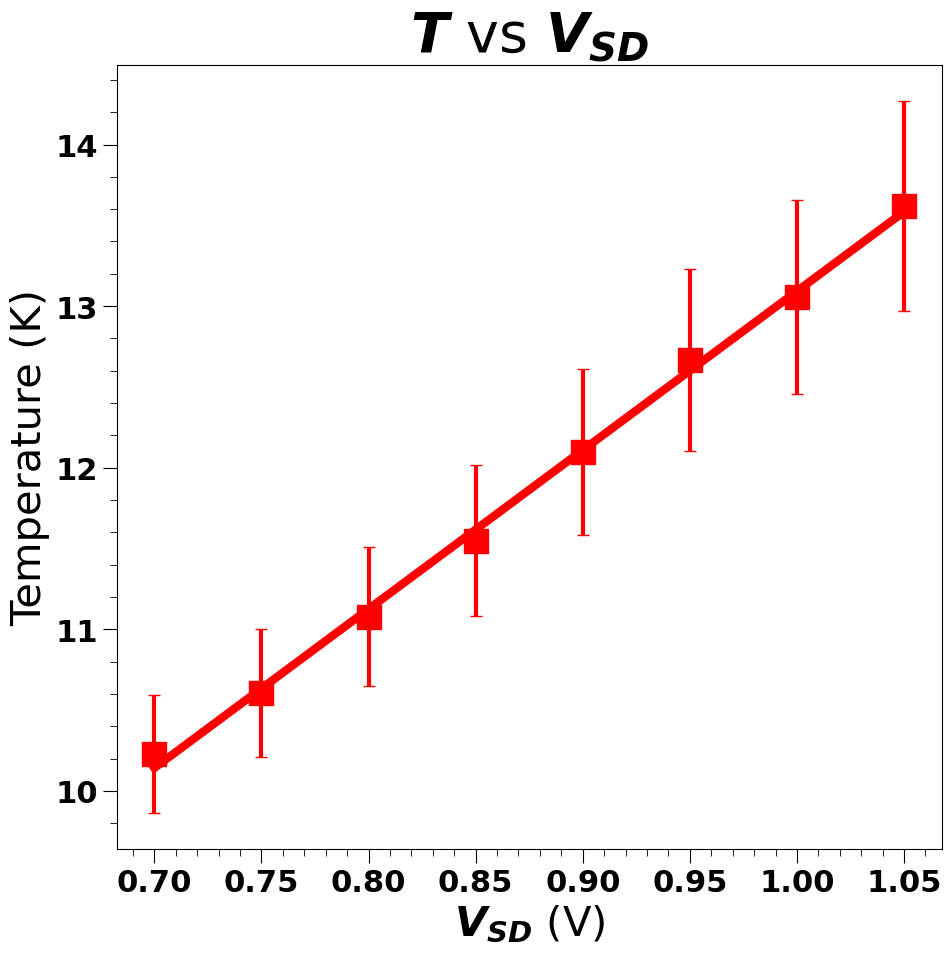

In [150]:
for i in [0,12]:
    plot_diffusion(dps[i+13],dps[i],-60,fit_scat=False)[0].savefig(
        f'./Luc Folder/conversionforfig/DTfit{gates[i]}.png')

    figure4=plt.figure()
    plt.minorticks_on()
    #plt.title(f'{gates[i]}V')
    plt.ylabel("log D",fontsize=30)
    plt.xlabel('1/T',fontsize=30)
    plt.scatter(np.reciprocal(tmpvs[i]),np.log(D_heaters[i]),label='Remote Heating',s=300)
    plt.scatter(np.reciprocal(temps[i]),np.log(D_sds[i]),
                label='Direct Heating',s=300,color='red',marker='s')
    #plt.errorbar(np.log(D_sds[i]),np.reciprocal(temps[i]),yerr=stderror_invts[i],
                #linewidth=3,linestyle='none',color='red',zorder=0,capsize=4)
    plt.plot(results[i].slope*np.log(D_heaters[i])+results[i].intercept
             ,np.log(D_heaters[i]),linewidth=6,zorder=0,color='C0')
    plt.plot(results[i].slope*np.log(D_sds[i])+results[i].intercept
             ,np.log(D_sds[i]),linewidth=6,zorder=0,color='C0',linestyle='--')
    plt.legend()
    plt.tick_params(axis='both', which='major', length=10)
    plt.tick_params(axis='both', which='minor', length=5)
    plt.title('1',fontsize=40,pad=10)
    plt.tight_layout()
    figure6=plt.figure()
    plt.minorticks_on()
    plt.title(r'$T$ vs $V_{SD}$',fontsize=40,pad=10)
    plt.xlabel("$V_{SD}$ (V)",fontsize=30)
    plt.ylabel('Temperature (K)',fontsize=30)
    x=volts
    y=temps
    plt.scatter(x[i],y[i],label=f'{gate}V',color='red',marker='s',s=300)
    result=scipy.stats.linregress(x[i],y[i])
    plt.plot(x[i],result.slope*np.array(x[i])+result.intercept,linewidth=6,zorder=0,color='red')
    plt.errorbar(x[i],y[i],color='red',yerr=errors_temp[i],linestyle='none',linewidth=3,capsize=4)
    plt.tick_params(axis='both', which='major', length=10)
    plt.tick_params(axis='both', which='minor', length=5)

    plt.tight_layout()
    figure4.savefig(f'./Luc Folder/conversionforfig/logDinvT{gates[i]}.png')
    figure6.savefig(f'./Luc Folder/conversionforfig/VT{gates[i]}.png')